# House Prices: исследовательский анализ

Цель — изучить признаки, пропуски, выбросы и связь с `SalePrice`. Сохранённые графики и выводы относятся к исходному EDA. Код запускается из корня проекта; обучение моделей вынесено в пайплайны.


In [33]:
!{sys.executable} -m pip install pandas matplotlib seaborn numpy scikit-learn category-encoders


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [35]:
data = pd.read_csv("classic_ml_pipeline_v8/data/train.csv")

In [36]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

Разделим признаки на 5 категорий Числовые непрерывные, Числовые дискретные, Категориальные номинальные, Категориальные порядковые, Временные.

Числовые непрерывные: LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal

Числовые дискретные: OverallQual, OverallCond, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars

Категориальные номинальные: MSSubClass, MSZoning, Street, Alley, LandContour, Utilities, LotConfig, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation, Heating, CentralAir, Electrical, GarageType, MiscFeature, SaleType, SaleCondition

Категориальные порядковые: LotShape, LandSlope, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, Functional, FireplaceQu, GarageFinish, GarageQual, GarageCond, PavedDrive, PoolQC, Fence

Временные: YearBuilt, YearRemodAdd, GarageYrBlt, MoSold, YrSold

In [37]:
continuous_features = [
    "LotFrontage",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
]

discrete_features = [
    "OverallQual",
    "OverallCond",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
]

nominal_features = [
    "MSSubClass",
    "MSZoning",
    "Street",
    "Alley",
    "LandContour",
    "Utilities",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
]

ordinal_features = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence",
]

temporal_features = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]

continuous = data[continuous_features]
discrete = data[discrete_features]
nominal = data[nominal_features]
ordinal = data[ordinal_features]
temporal = data[temporal_features]

Изучим целевую переменную.

In [38]:
data["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: ylabel='SalePrice'>

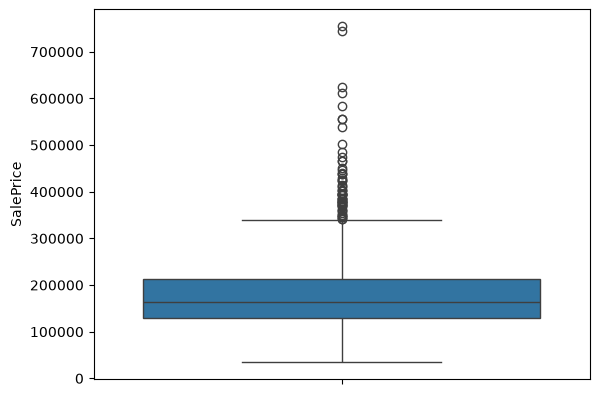

In [39]:
sns.boxplot(data["SalePrice"])

<Axes: xlabel='SalePrice', ylabel='Count'>

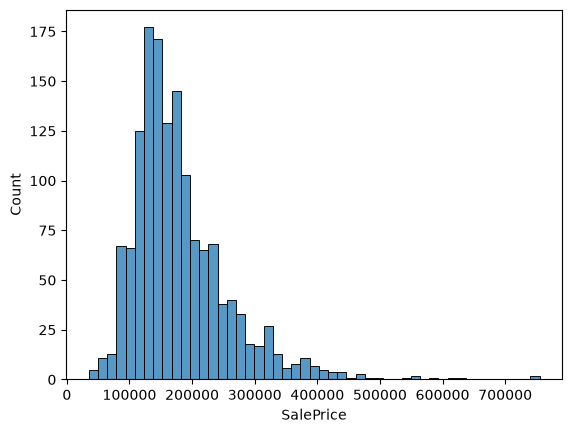

In [40]:
sns.histplot(data["SalePrice"])

Распределение SalePrice отклоняется от нормального и имеет выраженную положительную асимметрию: основная масса домов находится в более низком и среднем ценовом диапазоне, а справа наблюдается длинный хвост из небольшого числа дорогих домов. Также есть 7 аномальных объекта у которых цена >500000.

Так как мы определили 5 категорий признаков проанализируем как они связаны с таргетом.
Сначала посмотрим на численные признаки.
По-моему мнению, наиболее важные признаки при выборе дома это LotArea, GrLivArea, OverallCond, OverallQual, TotRmsAbvGrd.

Непрерывные

<Axes: xlabel='LotArea', ylabel='SalePrice'>

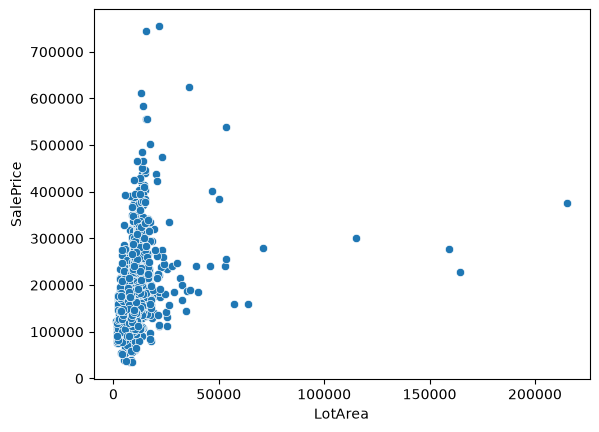

In [41]:
sns.scatterplot(x=data["LotArea"], y=data["SalePrice"])

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

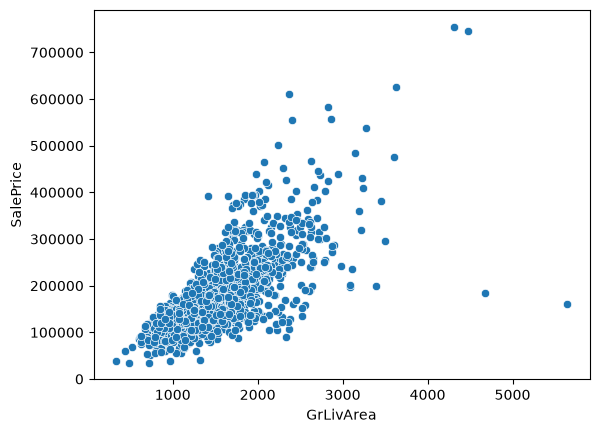

In [42]:
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])

Среди рассмотренных непрерывных признаков GrLivArea показывает сильную положительную связь с SalePrice, тогда как связь LotArea заметно слабее и содержит большой разброс. В обоих признаках присутствуют потенциальные выбросы, особенно при больших значениях площади.

Дискретные

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

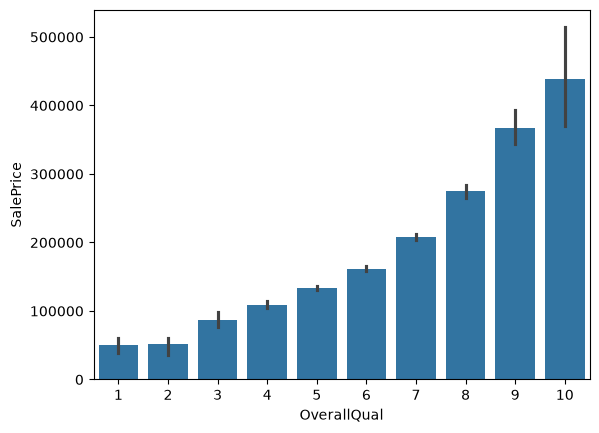

In [43]:
sns.barplot(x="OverallQual", y="SalePrice", data=data)

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

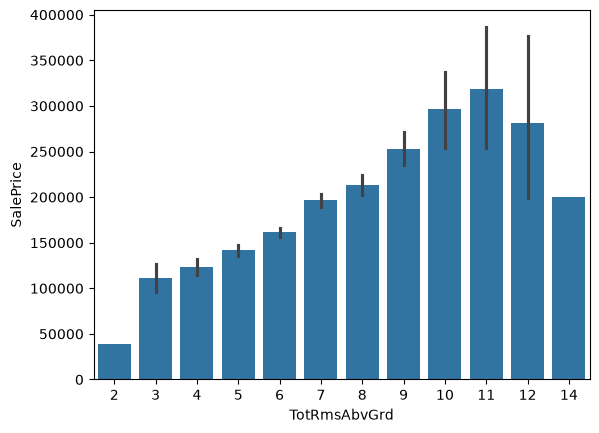

In [44]:
sns.barplot(x="TotRmsAbvGrd", y="SalePrice", data=data)

In [45]:
data[data["TotRmsAbvGrd"].isin([10, 11, 12, 14])][
    "TotRmsAbvGrd"
].value_counts().sort_index()

TotRmsAbvGrd
10    47
11    18
12    11
14     1
Name: count, dtype: int64

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

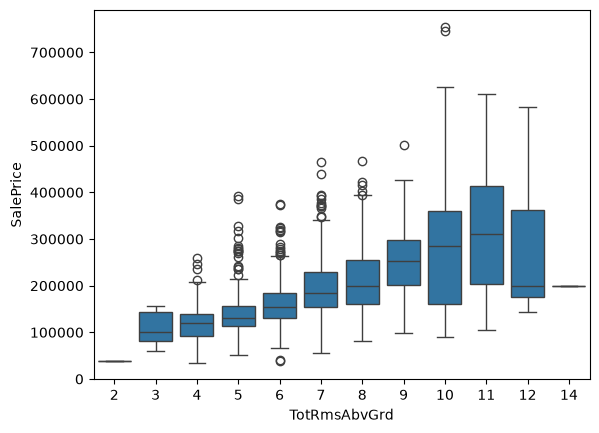

In [46]:
sns.boxplot(x="TotRmsAbvGrd", y="SalePrice", data=data)

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

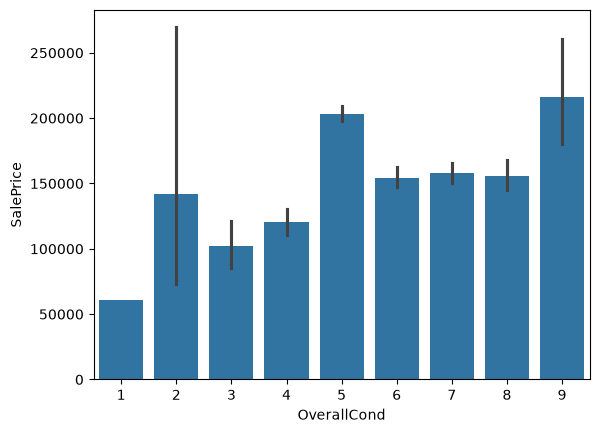

In [47]:
sns.barplot(x="OverallCond", y="SalePrice", data=data)

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

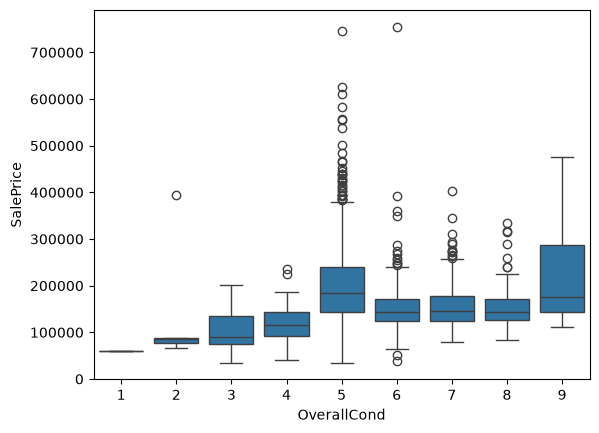

In [48]:
sns.boxplot(x="OverallCond", y="SalePrice", data=data)

Среди рассмотренных дискретных признаков наиболее выраженную связь с SalePrice показывает OverallQual: с ростом общей оценки качества цена дома заметно и практически монотонно увеличивается.
TotRmsAbvGrd также показывает положительную тенденцию — при увеличении числа комнат цена в среднем растёт, однако для редких больших значений зависимость становится нестабильной из-за малого количества наблюдений и большого разброса.
OverallCond показывает значительно более слабую и немонотонную связь с ценой: повышение оценки состояния дома не приводит к последовательному росту SalePrice

In [49]:
data[continuous_features].corrwith(data["SalePrice"]).sort_values(ascending=False)

GrLivArea        0.708624
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
MasVnrArea       0.477493
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
LotArea          0.263843
BsmtUnfSF        0.214479
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
MiscVal         -0.021190
LowQualFinSF    -0.025606
EnclosedPorch   -0.128578
dtype: float64

In [50]:
data[discrete_features].corrwith(data["SalePrice"]).sort_values(ascending=False)

OverallQual     0.790982
GarageCars      0.640409
FullBath        0.560664
TotRmsAbvGrd    0.533723
Fireplaces      0.466929
HalfBath        0.284108
BsmtFullBath    0.227122
BedroomAbvGr    0.168213
BsmtHalfBath   -0.016844
OverallCond    -0.077856
KitchenAbvGr   -0.135907
dtype: float64

По корреляции с SalePrice сильнее всего выделяются OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath и TotRmsAbvGrd. На эти признаки стоит обратить особое внимание при дальнейшем анализе. OverallCond практически не имеет линейной связи с ценой. Также некоторые сильные признаки описывают похожие характеристики дома, например GarageCars и GarageArea, поэтому дальше стоит проверить мультиколлинеарность между признаками.

Так теперь проанализируем категориальные признаки, в порядковых признаках я думаю всё важно потому что это оценивает состояния покупаемого объекта и на это будут обращать внимание, посмотрим именно на номинальные   

посмотрим какие значения эти признаки могут принимать и сколько раз встречаются определённые значения, какая у них средняя и медианная цена


MSSubClass
              median           mean  count
MSSubClass                                
20          159250.0  185224.811567    536
60          215200.0  239948.501672    299
50          132000.0  143302.972222    144
120         192000.0  200779.080460     87
30           99900.0   95829.724638     69
160         146000.0  138647.380952     63
70          156000.0  166772.416667     60
80          166500.0  169736.551724     58
90          135980.0  133541.076923     52
190         128250.0  129613.333333     30
85          140750.0  147810.000000     20
75          163500.0  192437.500000     16
45          107500.0  108591.666667     12
180          88500.0  102300.000000     10
40          142500.0  156125.000000      4


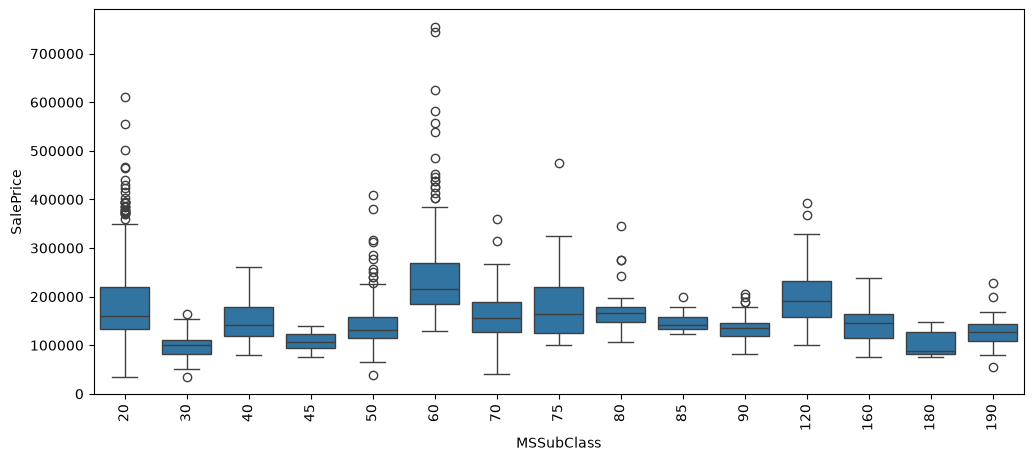


MSZoning
            median           mean  count
MSZoning                                
RL        174000.0  191004.994787   1151
RM        120500.0  126316.830275    218
FV        205950.0  214014.061538     65
RH        136500.0  131558.375000     16
C (all)    74700.0   74528.000000     10


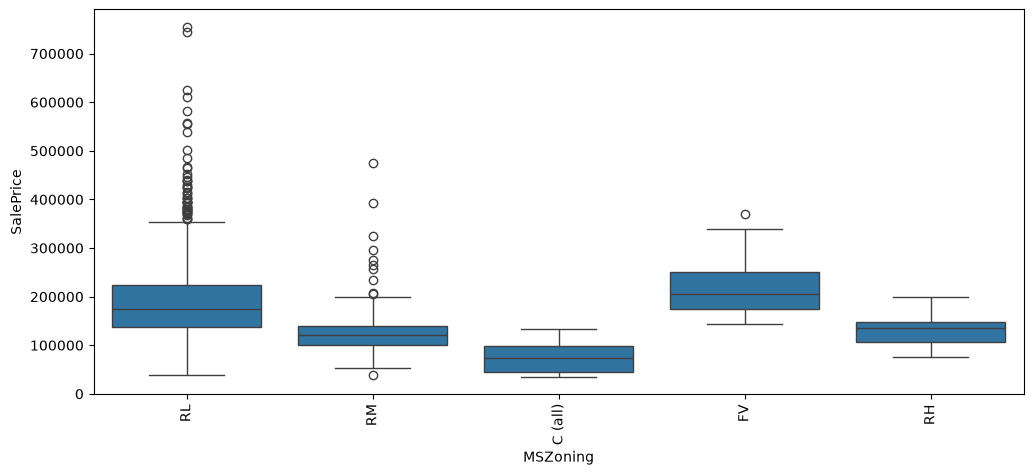


Street
          median           mean  count
Street                                
Pave    163000.0  181130.538514   1454
Grvl    114250.0  130190.500000      6


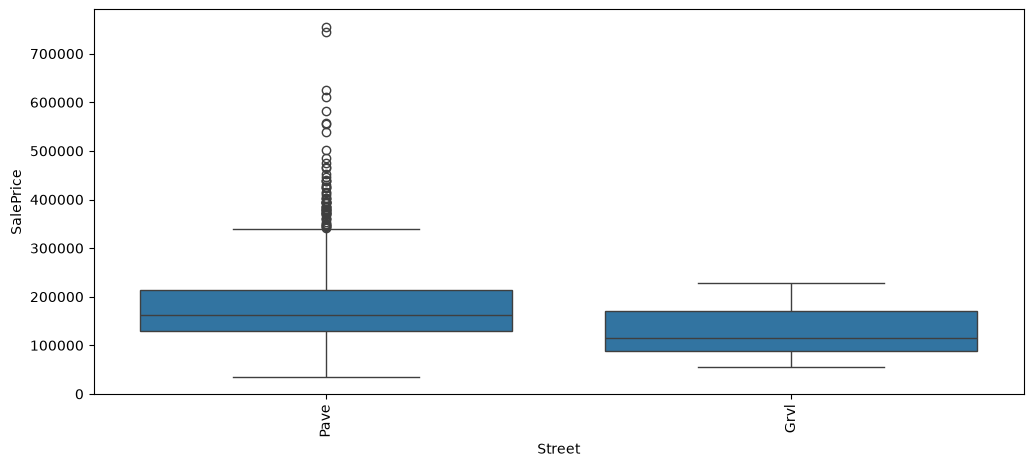


Alley
         median           mean  count
Alley                                
Grvl   119500.0  122219.080000     50
Pave   172500.0  168000.585366     41


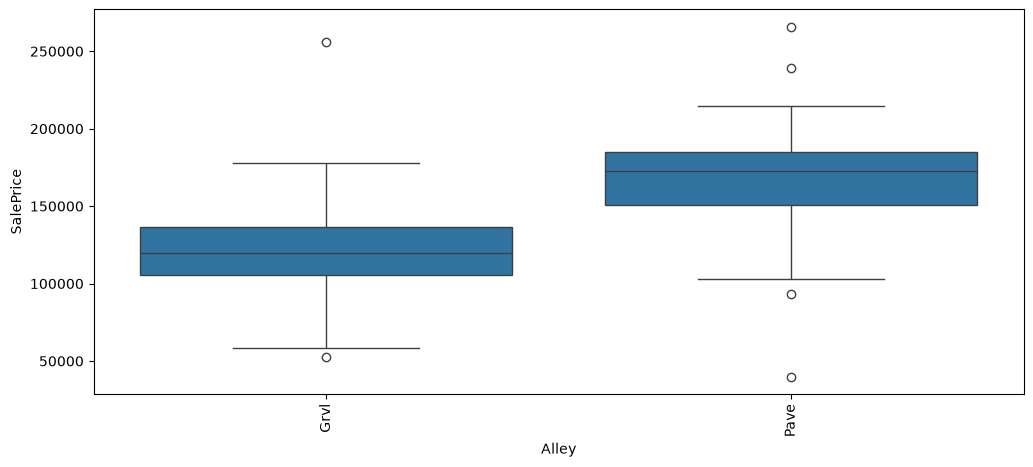


LandContour
               median           mean  count
LandContour                                
Lvl          162900.0  180183.746758   1311
Bnk          139400.0  143104.079365     63
HLS          222250.0  231533.940000     50
Low          190000.0  203661.111111     36


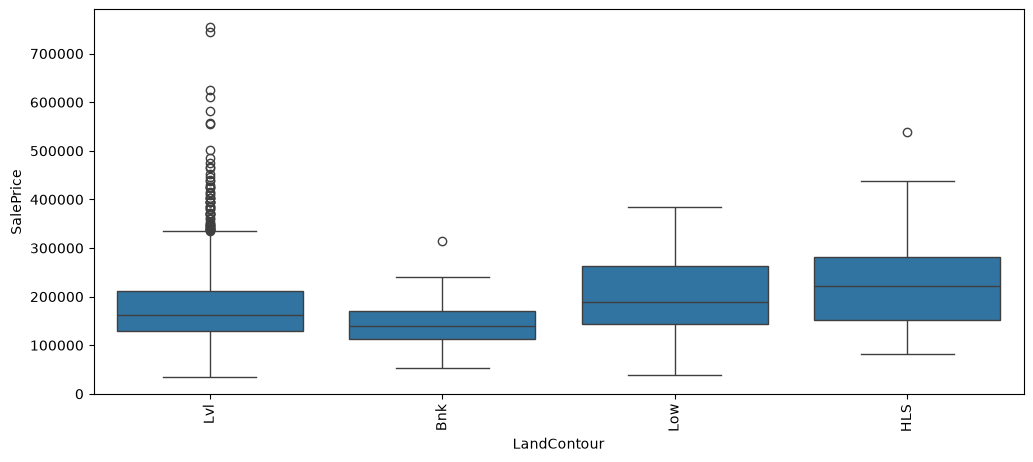


Utilities
             median          mean  count
Utilities                               
AllPub     163000.0  180950.95682   1459
NoSeWa     137500.0  137500.00000      1


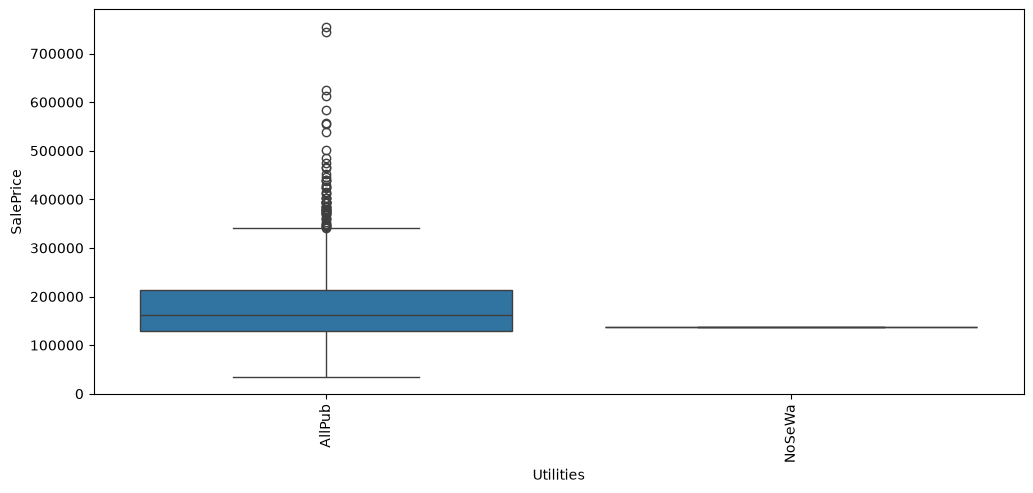


LotConfig
             median           mean  count
LotConfig                                
Inside     159697.5  176938.047529   1052
Corner     160000.0  181623.425856    263
CulDSac    199262.0  223854.617021     94
FR2        165000.0  177934.574468     47
FR3        195450.0  208475.000000      4


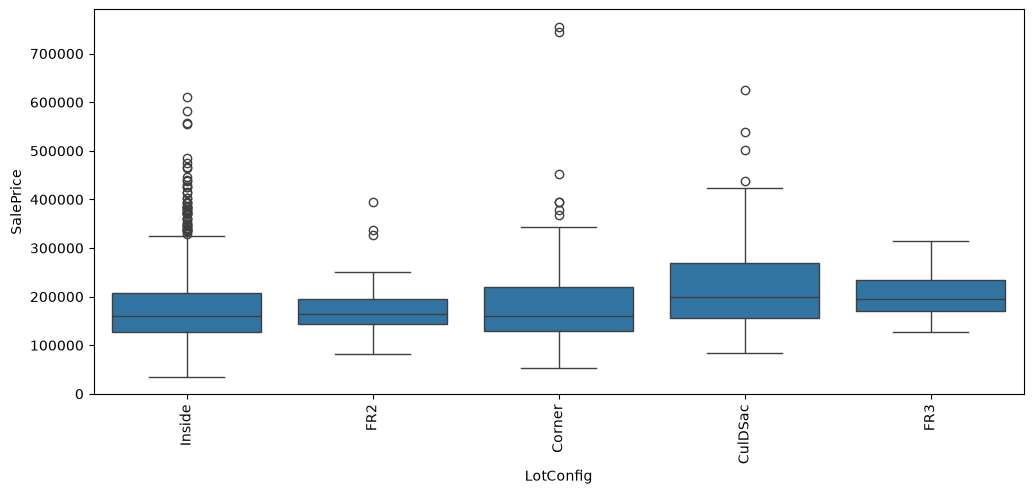


Neighborhood
                median           mean  count
Neighborhood                                
NAmes         140000.0  145847.080000    225
CollgCr       197200.0  197965.773333    150
OldTown       119000.0  128225.300885    113
Edwards       121750.0  128219.700000    100
Somerst       225500.0  225379.837209     86
Gilbert       181000.0  192854.506329     79
NridgHt       315000.0  316270.623377     77
Sawyer        135000.0  136793.135135     74
NWAmes        182900.0  189050.068493     73
SawyerW       179900.0  186555.796610     59
BrkSide       124300.0  124834.051724     58
Crawfor       200624.0  210624.725490     51
Mitchel       153500.0  156270.122449     49
NoRidge       301500.0  335295.317073     41
Timber        228475.0  242247.447368     38
IDOTRR        103000.0  100123.783784     37
ClearCr       200250.0  212565.428571     28
StoneBr       278000.0  310499.000000     25
SWISU         139500.0  142591.360000     25
Blmngtn       191000.0  194870.882353    

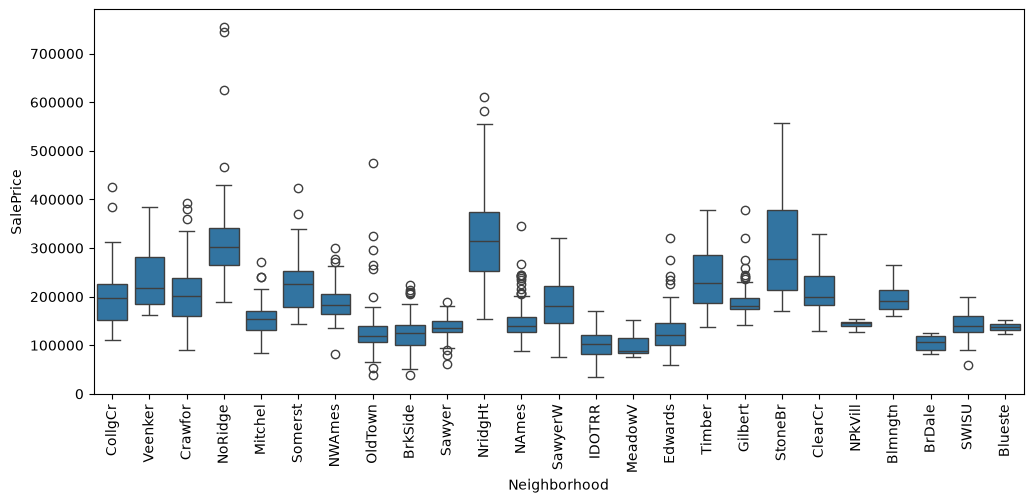


Condition1
              median           mean  count
Condition1                                
Norm        166500.0  184495.492063   1260
Feedr       140000.0  142475.481481     81
Artery      119550.0  135091.666667     48
RRAn        171495.0  184396.615385     26
PosN        200000.0  215184.210526     19
RRAe        142500.0  138400.000000     11
PosA        212500.0  225875.000000      8
RRNn        214000.0  212400.000000      5
RRNe        190750.0  190750.000000      2


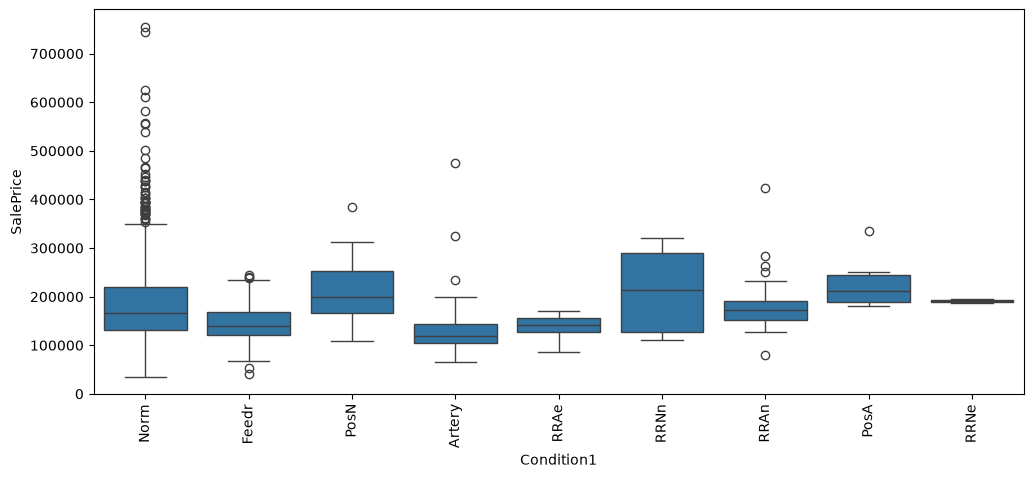


Condition2
              median           mean  count
Condition2                                
Norm        163500.0  181169.405536   1445
Feedr       127500.0  121166.666667      6
Artery      106500.0  106500.000000      2
PosN        284875.0  284875.000000      2
RRNn         96750.0   96750.000000      2
PosA        325000.0  325000.000000      1
RRAe        190000.0  190000.000000      1
RRAn        136905.0  136905.000000      1


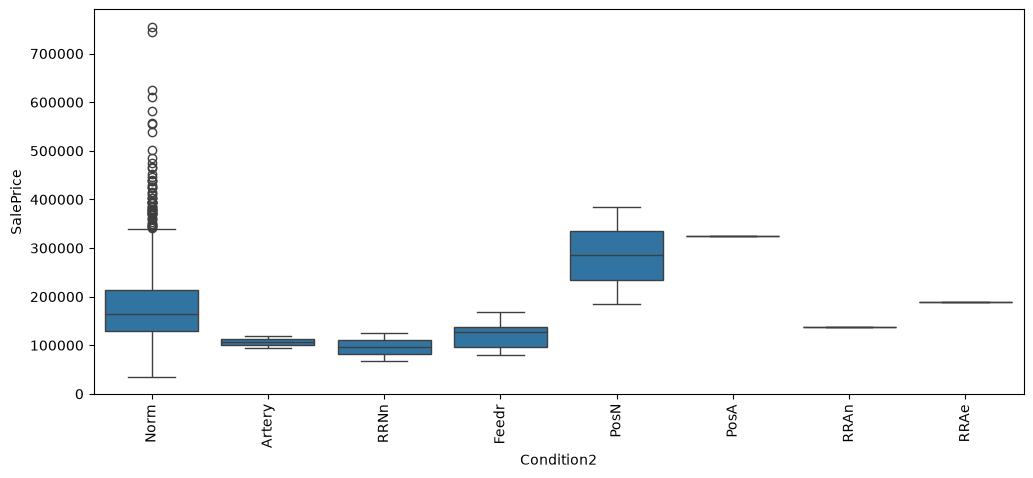


BldgType
            median           mean  count
BldgType                                
1Fam      167900.0  185763.807377   1220
TwnhsE    172200.0  181959.342105    114
Duplex    135980.0  133541.076923     52
Twnhs     137500.0  135911.627907     43
2fmCon    127500.0  128432.258065     31


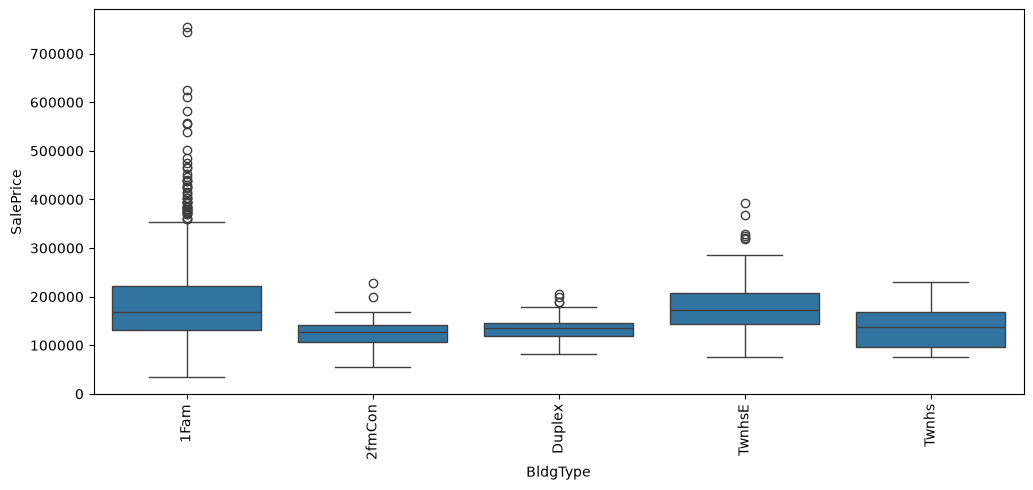


HouseStyle
              median           mean  count
HouseStyle                                
1Story      154750.0  175985.477961    726
2Story      190000.0  210051.764045    445
1.5Fin      132000.0  143116.740260    154
SLvl        164500.0  166703.384615     65
SFoyer      135960.0  135074.486486     37
1.5Unf      111250.0  110150.000000     14
2.5Unf      133900.0  157354.545455     11
2.5Fin      194000.0  220000.000000      8


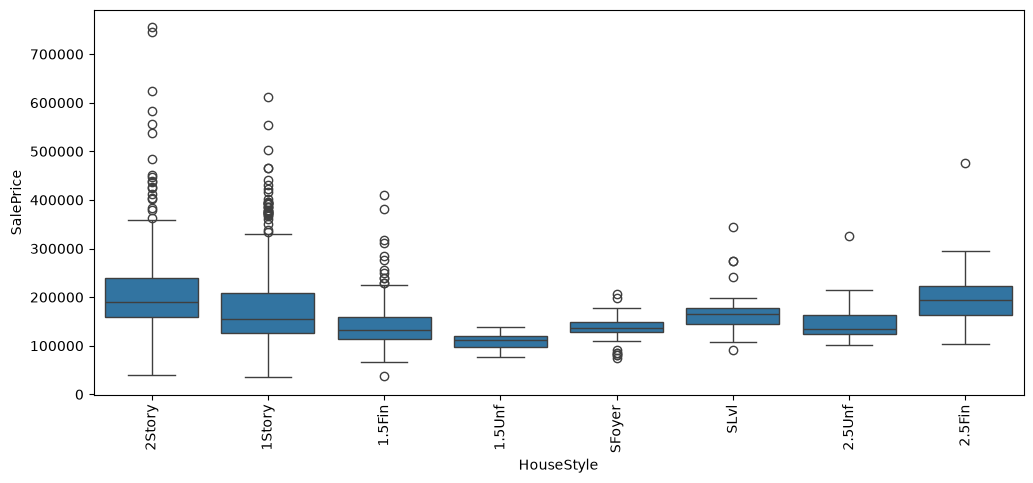


RoofStyle
             median           mean  count
RoofStyle                                
Gable      160000.0  171483.956179   1141
Hip        176500.0  218876.933566    286
Flat       185000.0  194690.000000     13
Gambrel    139000.0  148909.090909     11
Mansard    175000.0  180568.428571      7
Shed       225000.0  225000.000000      2


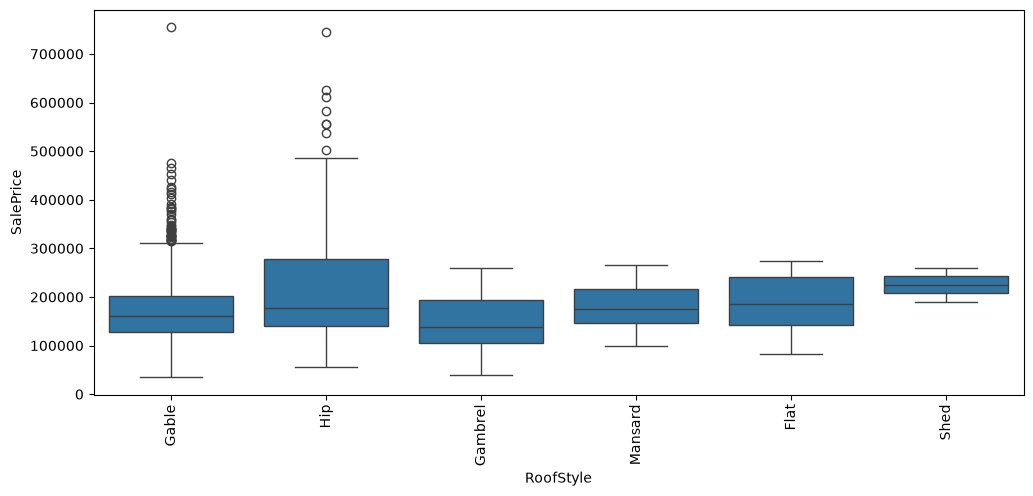


RoofMatl
            median           mean  count
RoofMatl                                
CompShg   162000.0  179803.679219   1434
Tar&Grv   167000.0  185406.363636     11
WdShngl   332500.0  390250.000000      6
WdShake   242000.0  241400.000000      5
ClyTile   160000.0  160000.000000      1
Membran   241500.0  241500.000000      1
Metal     180000.0  180000.000000      1
Roll      137000.0  137000.000000      1


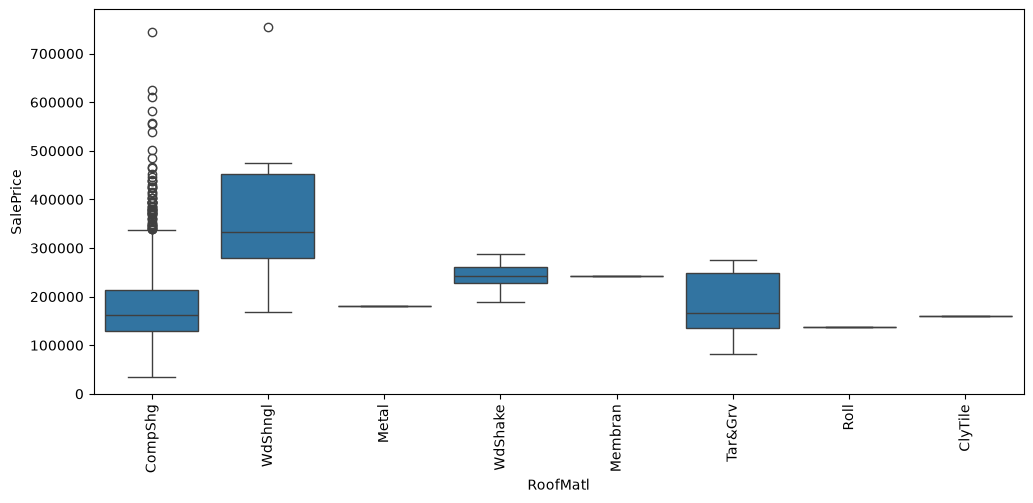


Exterior1st
               median           mean  count
Exterior1st                                
VinylSd      200000.0  213732.900971    515
HdBoard      149900.0  163077.450450    222
MetalSd      139000.0  149422.177273    220
Wd Sdng      138943.5  149841.645631    206
Plywood      167450.0  175942.379630    108
CemntBd      236500.0  231690.655738     61
BrkFace      165750.0  194573.000000     50
WdShing      128700.0  150655.076923     26
Stucco       144000.0  162990.000000     25
AsbShng      108000.0  107385.550000     20
BrkComm       71000.0   71000.000000      2
Stone        258500.0  258500.000000      2
AsphShn      100000.0  100000.000000      1
CBlock       105000.0  105000.000000      1
ImStucc      262000.0  262000.000000      1


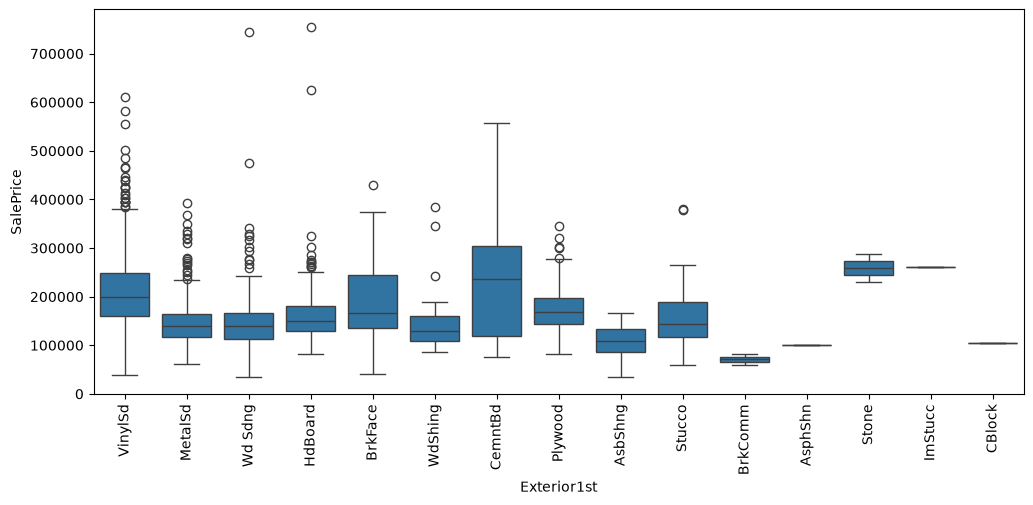


Exterior2nd
               median           mean  count
Exterior2nd                                
VinylSd      200070.5  214432.460317    504
MetalSd      138750.0  149803.172897    214
HdBoard      155000.0  167661.565217    207
Wd Sdng      138000.0  148386.065990    197
Plywood      160750.0  168112.387324    142
CmentBd      238750.0  230093.833333     60
Wd Shng      138225.0  161328.947368     38
Stucco       142000.0  155905.153846     26
BrkFace      160000.0  195818.000000     25
AsbShng      111000.0  114060.550000     20
ImStucc      187600.0  252070.000000     10
Brk Cmn      147000.0  126714.285714      7
Stone        177000.0  158224.800000      5
AsphShn      139000.0  138000.000000      3
CBlock       105000.0  105000.000000      1
Other        319000.0  319000.000000      1


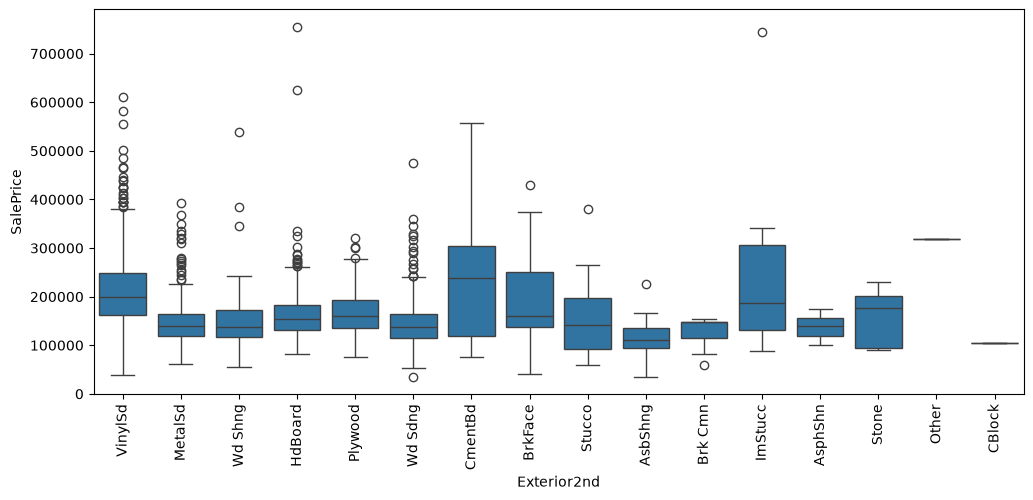


MasVnrType
              median           mean  count
MasVnrType                                
BrkFace     181000.0  204691.871910    445
Stone       246839.0  265583.625000    128
BrkCmn      139000.0  146318.066667     15


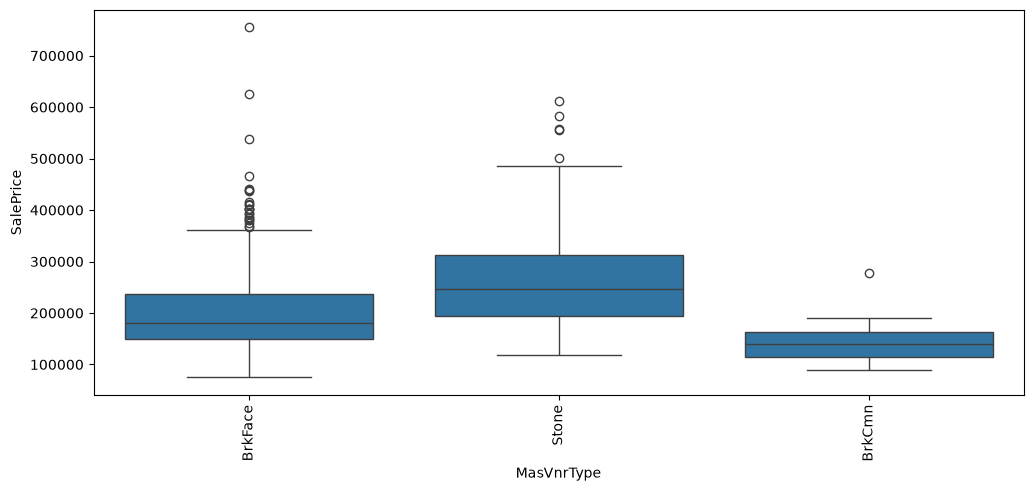


Foundation
              median           mean  count
Foundation                                
PConc       205000.0  225230.442040    647
CBlock      141500.0  149805.714511    634
BrkTil      125250.0  132291.075342    146
Slab        104150.0  107365.625000     24
Stone       126500.0  165959.166667      6
Wood        164000.0  185666.666667      3


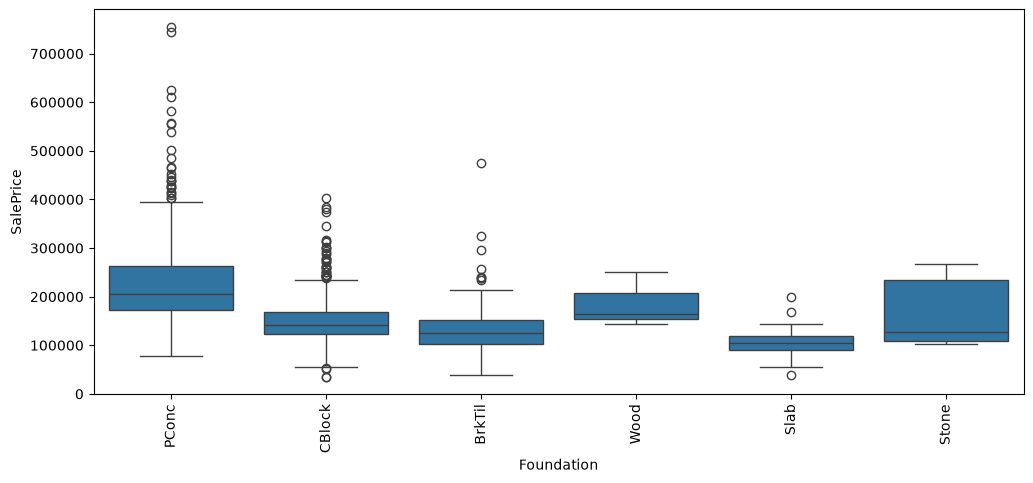


Heating
           median           mean  count
Heating                                
GasA     164500.0  182021.195378   1428
GasW     134950.0  166632.166667     18
Grav      79000.0   75271.428571      7
Wall      91450.0   92100.000000      4
OthW     125750.0  125750.000000      2
Floor     72500.0   72500.000000      1


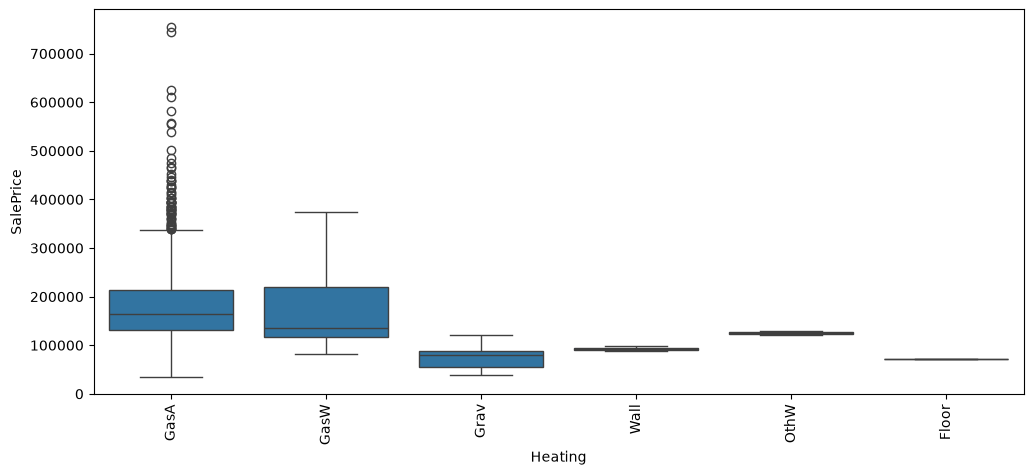


CentralAir
              median           mean  count
CentralAir                                
Y           168000.0  186186.709890   1365
N            98000.0  105264.073684     95


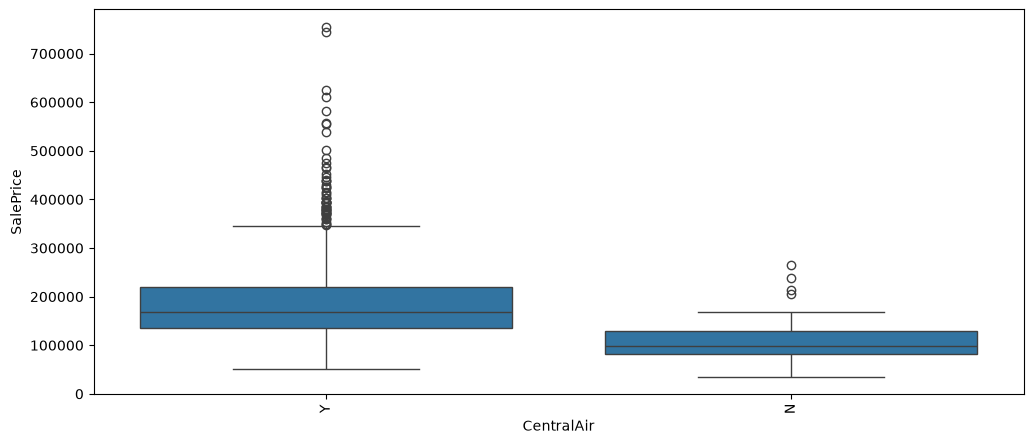


Electrical
              median           mean  count
Electrical                                
SBrkr       170000.0  186825.113193   1334
FuseA       121250.0  122196.893617     94
FuseF       115000.0  107675.444444     27
FuseP        82000.0   97333.333333      3
Mix          67000.0   67000.000000      1


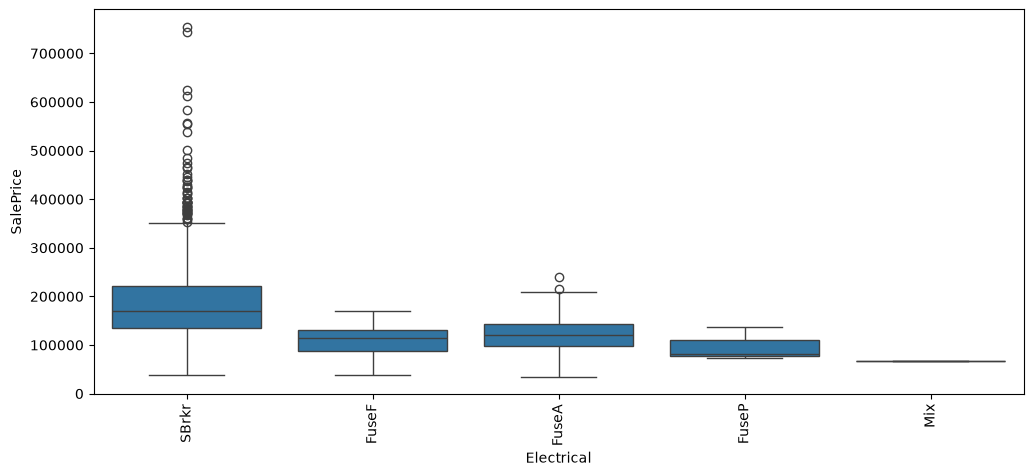


GarageType
              median           mean  count
GarageType                                
Attchd      185000.0  202892.656322    870
Detchd      129500.0  134091.162791    387
BuiltIn     227500.0  254751.738636     88
Basment     148000.0  160570.684211     19
CarPort     108000.0  109962.111111      9
2Types      159000.0  151283.333333      6


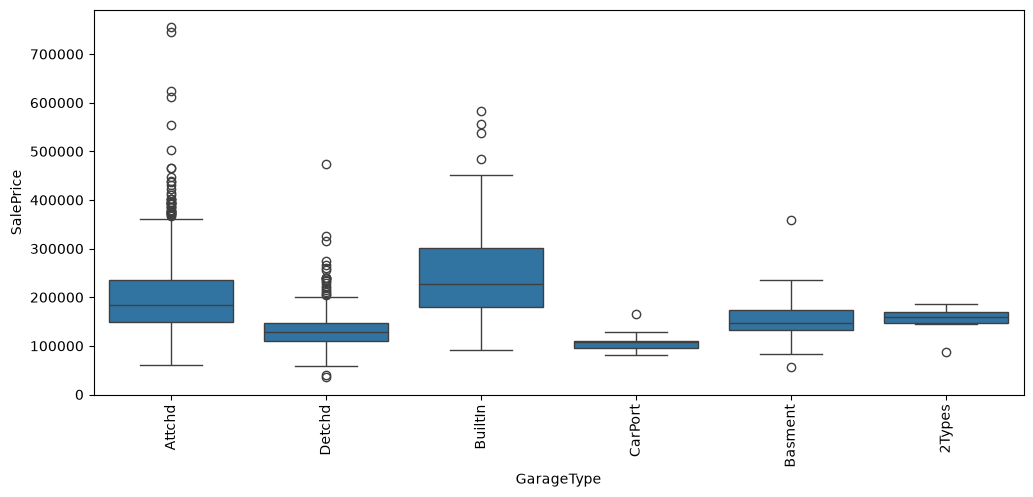


MiscFeature
               median           mean  count
MiscFeature                                
Shed         144000.0  151187.612245     49
Gar2         170750.0  170750.000000      2
Othr          94000.0   94000.000000      2
TenC         250000.0  250000.000000      1


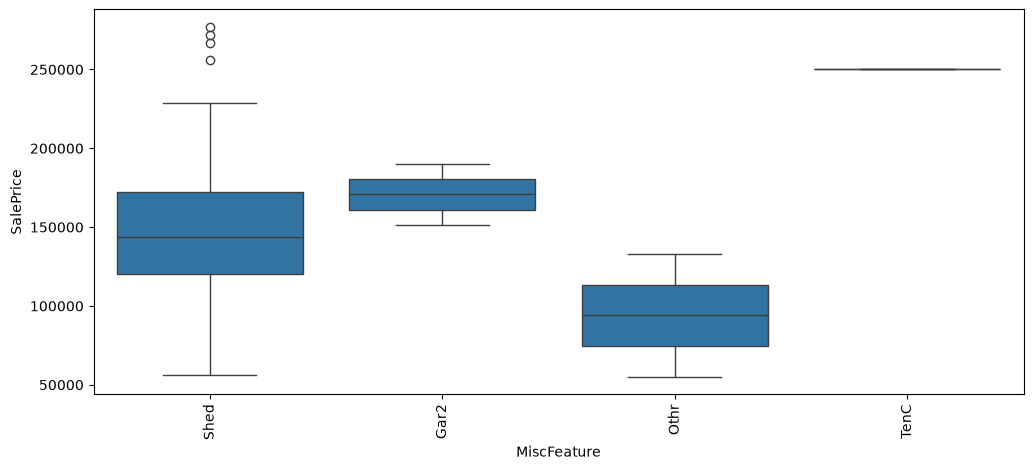


SaleType
            median           mean  count
SaleType                                
WD        158000.0  173401.836622   1267
New       247453.0  274945.418033    122
COD       139000.0  143973.255814     43
ConLD     140000.0  138780.888889      9
ConLI     125000.0  200390.000000      5
ConLw     144000.0  143700.000000      5
CWD       188750.0  210600.000000      4
Oth       116050.0  119850.000000      3
Con       269600.0  269600.000000      2


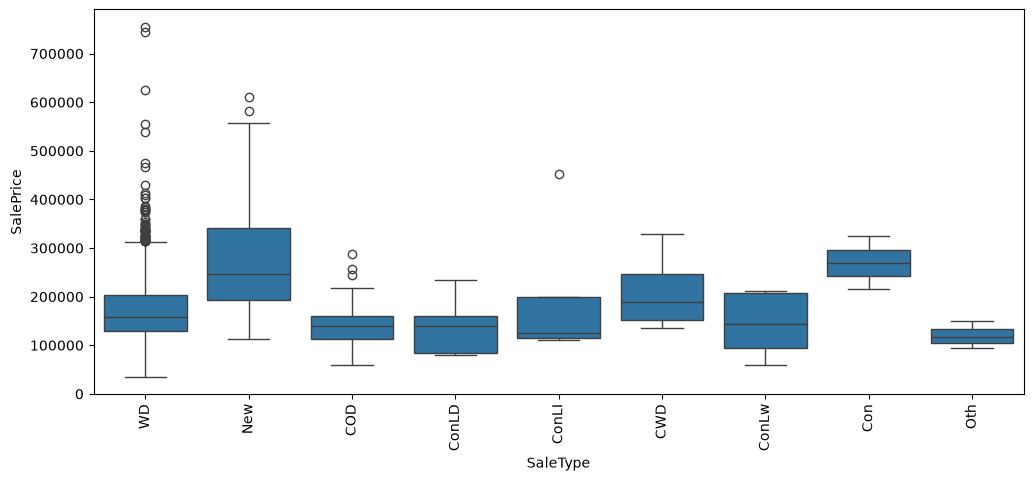


SaleCondition
                 median           mean  count
SaleCondition                                
Normal         160000.0  175202.219533   1198
Partial        244600.0  272291.752000    125
Abnorml        130000.0  146526.623762    101
Family         140500.0  149600.000000     20
Alloca         148145.0  167377.416667     12
AdjLand        104000.0  104125.000000      4


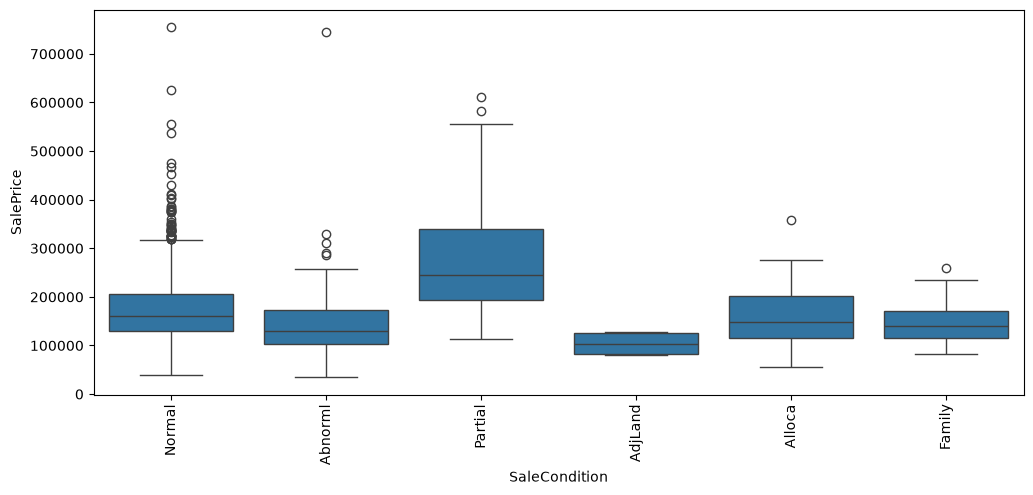

In [51]:
for col in nominal_features:
    print(f"\n{col}")
    print(
        data.groupby(col)["SalePrice"]
        .agg(["median", "mean", "count"])
        .sort_values("count", ascending=False)
    )
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=col, y="SalePrice", data=data)
    plt.xticks(rotation=90)
    plt.show()

Среди номинальных признаков наиболее заметные различия в распределении SalePrice наблюдаются у Neighborhood, HouseStyle, RoofStyle, Exterior1st, Exterior2nd, MasVnrType, Foundation, GarageType, SaleType и SaleCondition. У остальных рассмотренных признаков либо наблюдается сильный дисбаланс категорий, либо различия в цене между категориями выражены слабее. Окончательную полезность признаков стоит дополнительно проверить с помощью Mutual Information.

быстро проверим порядковые


LotShape
            median           mean  count
LotShape                                
Reg       146000.0  164754.818378    925
IR1       189000.0  206101.665289    484
IR2       221000.0  239833.365854     41
IR3       203570.0  216036.500000     10


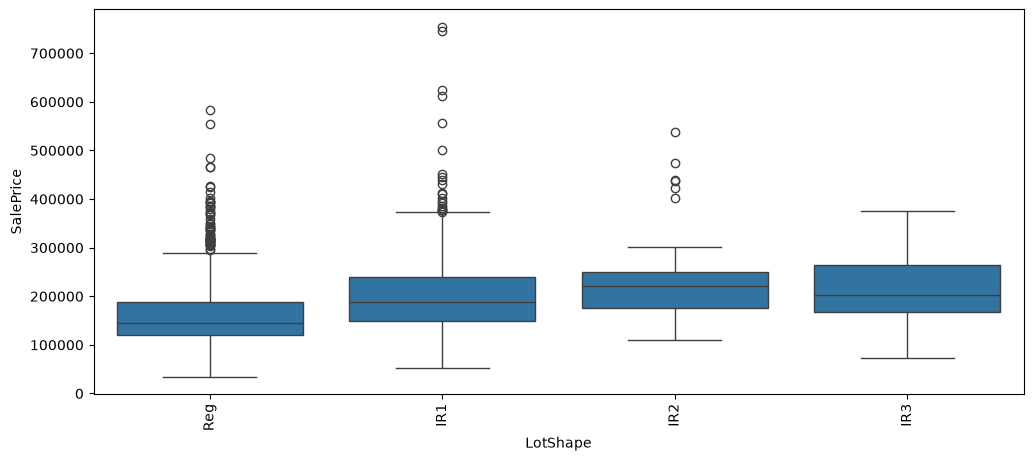


LandSlope
             median           mean  count
LandSlope                                
Gtl        161875.0  179956.799566   1382
Mod        186700.0  196734.138462     65
Sev        185000.0  204379.230769     13


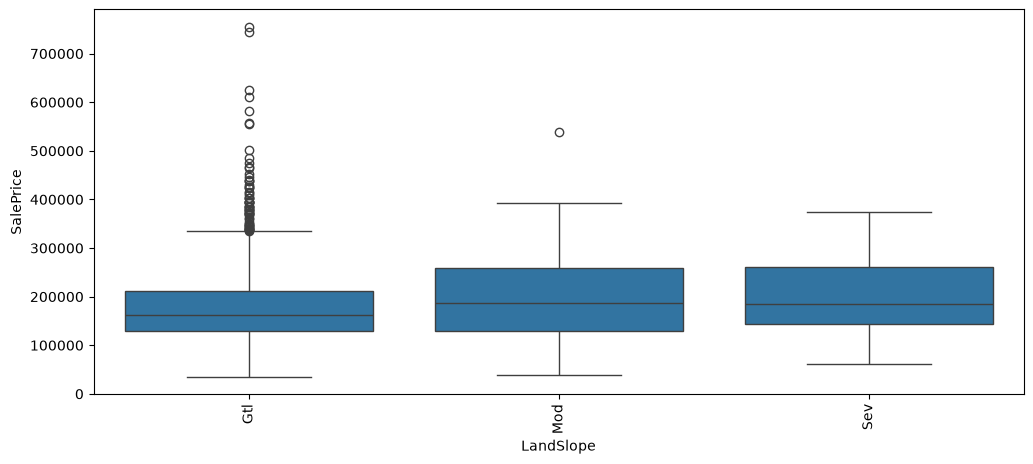


ExterQual
             median           mean  count
ExterQual                                
TA         139450.0  144341.313466    906
Gd         220000.0  231633.510246    488
Ex         364606.5  367360.961538     52
Fa          82250.0   87985.214286     14


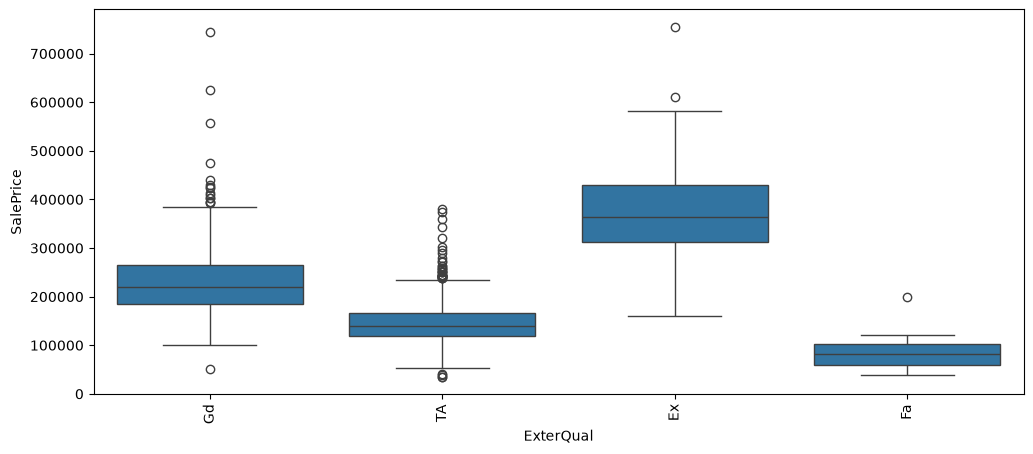


ExterCond
             median           mean  count
ExterCond                                
TA         167370.0  184034.896256   1282
Gd         151250.0  168897.568493    146
Fa          95750.0  102595.142857     28
Ex         161000.0  201333.333333      3
Po          76500.0   76500.000000      1


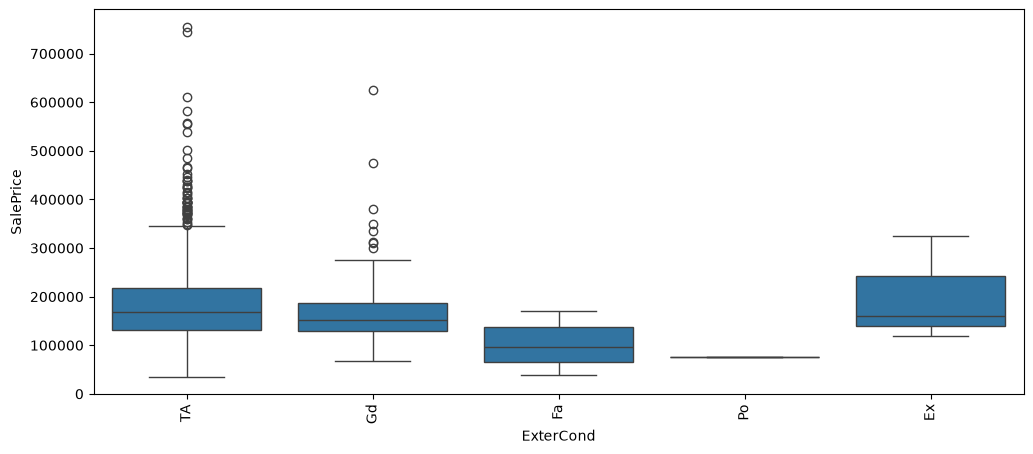


BsmtQual
            median           mean  count
BsmtQual                                
TA        135500.0  140759.818182    649
Gd        192070.0  202688.478964    618
Ex        318000.0  327041.041322    121
Fa        112000.0  115692.028571     35


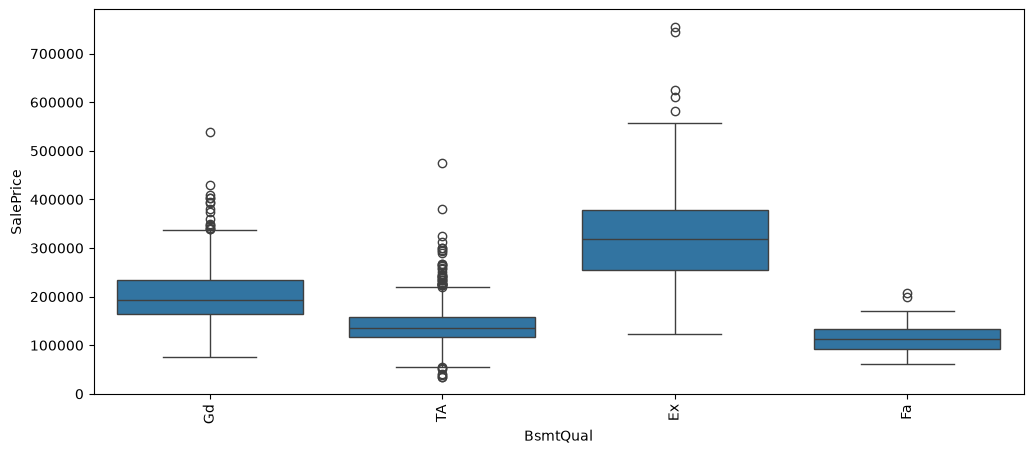


BsmtCond
            median           mean  count
BsmtCond                                
TA        165000.0  183632.620900   1311
Gd        193879.0  213599.907692     65
Fa        118500.0  121809.533333     45
Po         64000.0   64000.000000      2


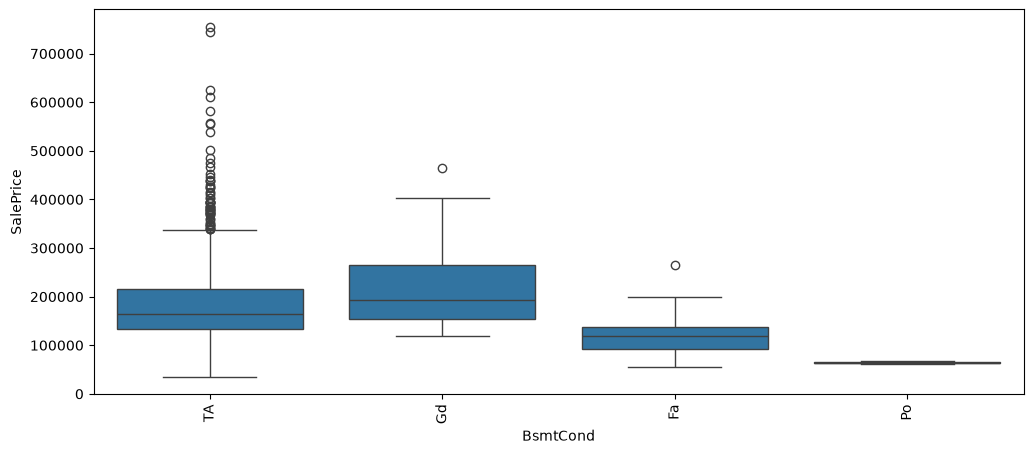


BsmtExposure
                median           mean  count
BsmtExposure                                
No            154000.0  165652.295908    953
Av            185850.0  206643.420814    221
Gd            226975.0  257689.805970    134
Mn            182450.0  192789.657895    114


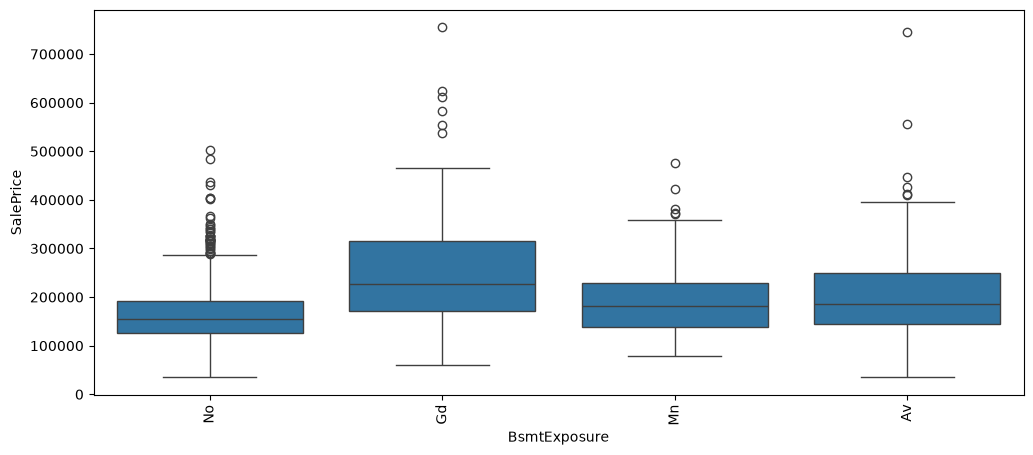


BsmtFinType1
                median           mean  count
BsmtFinType1                                
Unf           161750.0  170670.576744    430
GLQ           213750.0  235413.720096    418
ALQ           149250.0  161573.068182    220
BLQ           139100.0  149493.655405    148
Rec           142000.0  146889.248120    133
LwQ           139000.0  151852.702703     74


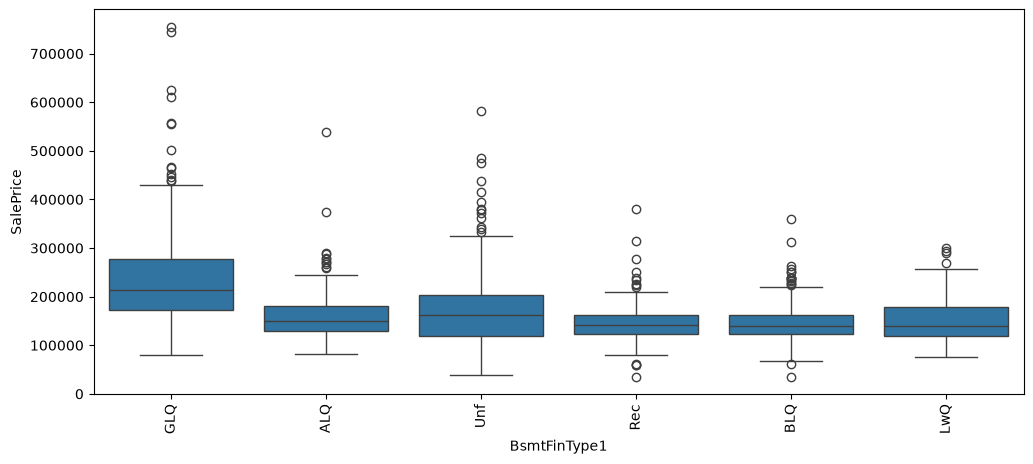


BsmtFinType2
                median           mean  count
BsmtFinType2                                
Unf           167000.0  184694.690287   1256
Rec           148750.0  164917.129630     54
LwQ           154000.0  164364.130435     46
BLQ           143000.0  151101.000000     33
ALQ           174900.0  209942.105263     19
GLQ           203125.0  180982.142857     14


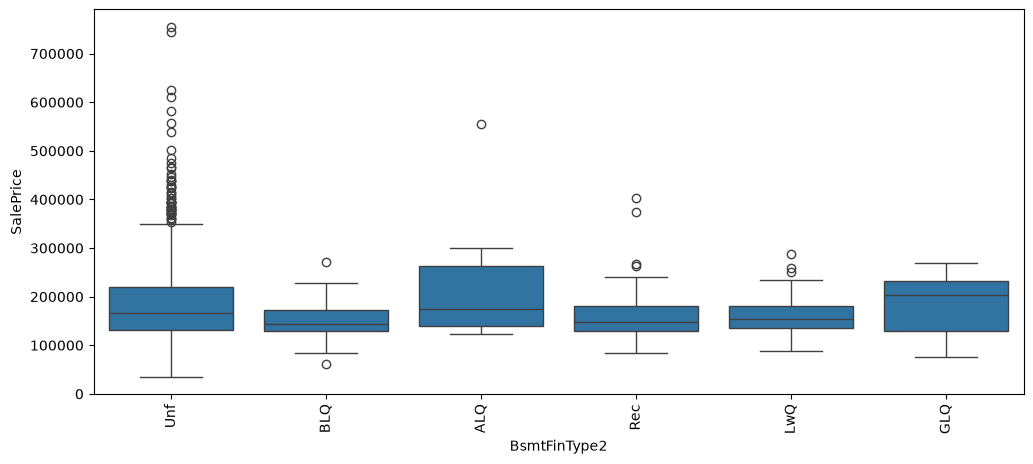


HeatingQC
             median           mean  count
HeatingQC                                
Ex         194700.0  214914.429150    741
TA         135000.0  142362.876168    428
Gd         152000.0  156858.871369    241
Fa         123500.0  123919.489796     49
Po          87000.0   87000.000000      1


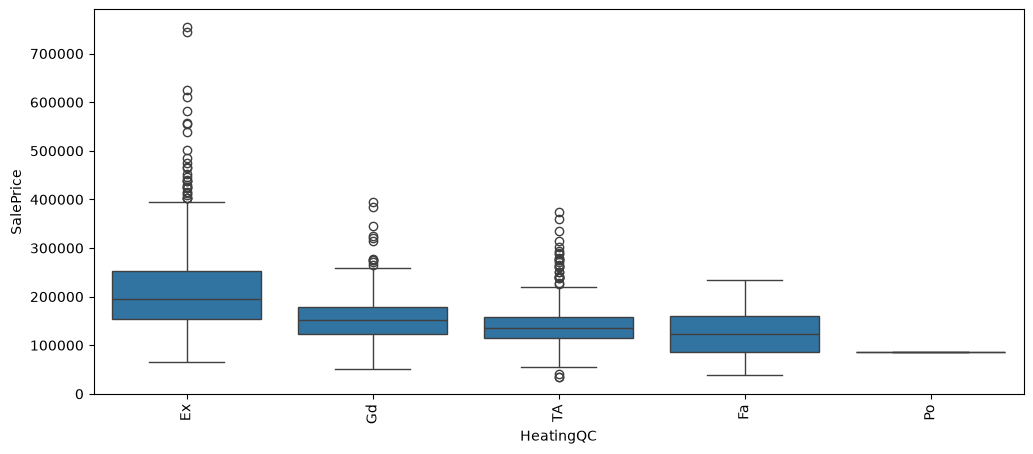


KitchenQual
               median           mean  count
KitchenQual                                
TA           137000.0  139962.511565    735
Gd           201400.0  212116.023891    586
Ex           316750.0  328554.670000    100
Fa           115000.0  105565.205128     39


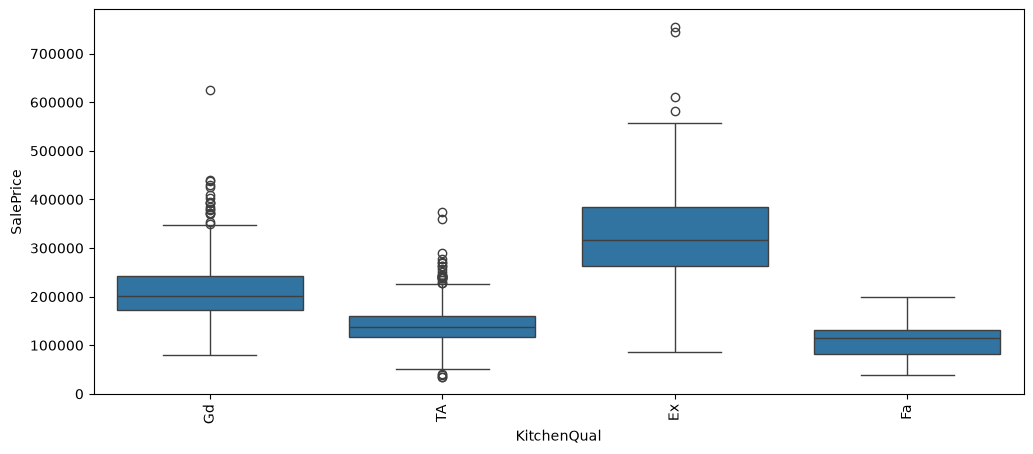


Functional
              median           mean  count
Functional                                
Typ         165500.0  183429.147059   1360
Min2        140000.0  144240.647059     34
Min1        139000.0  146385.483871     31
Mod         137900.0  168393.333333     15
Maj1        140750.0  153948.142857     14
Maj2         85000.0   85800.000000      5
Sev         129000.0  129000.000000      1


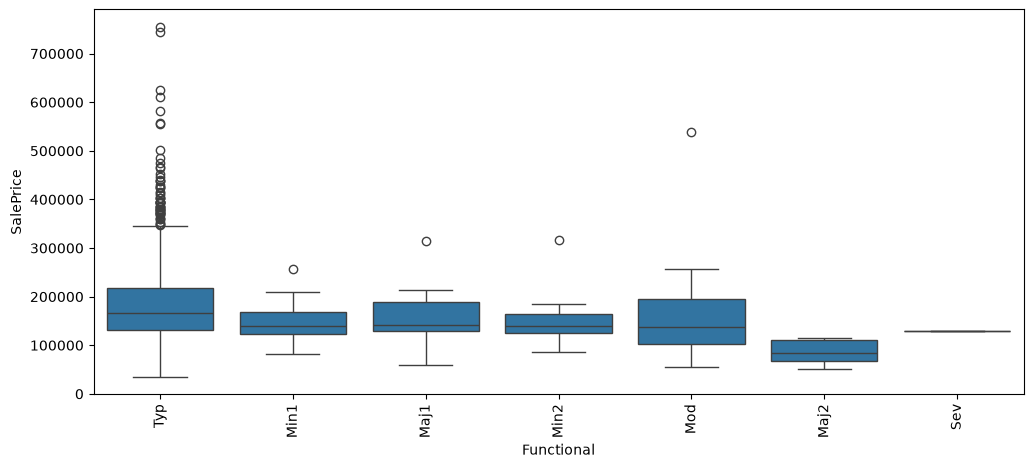


FireplaceQu
               median           mean  count
FireplaceQu                                
Gd           206950.0  226351.415789    380
TA           187500.0  205723.488818    313
Fa           158000.0  167298.484848     33
Ex           314250.0  337712.500000     24
Po           131500.0  129764.150000     20


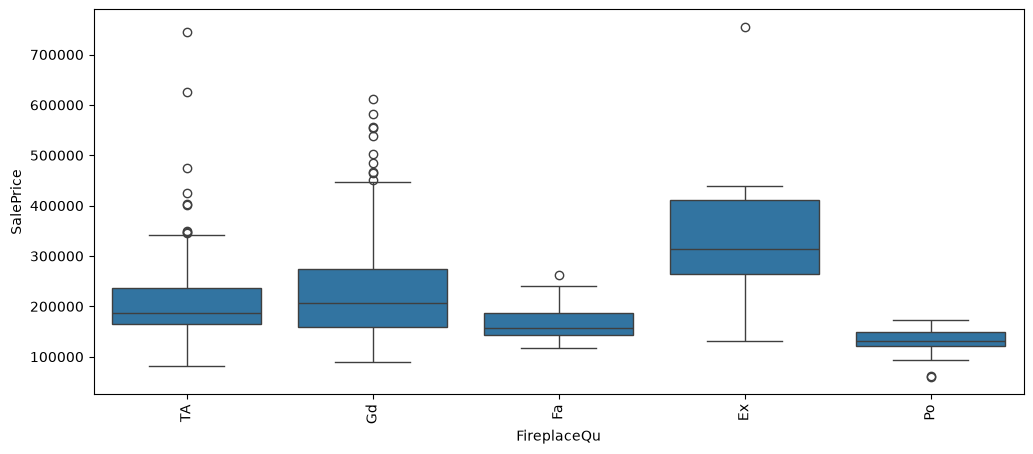


GarageFinish
                median           mean  count
GarageFinish                                
Unf           135000.0  142156.423140    605
RFn           190000.0  202068.869668    422
Fin           215000.0  240052.690341    352


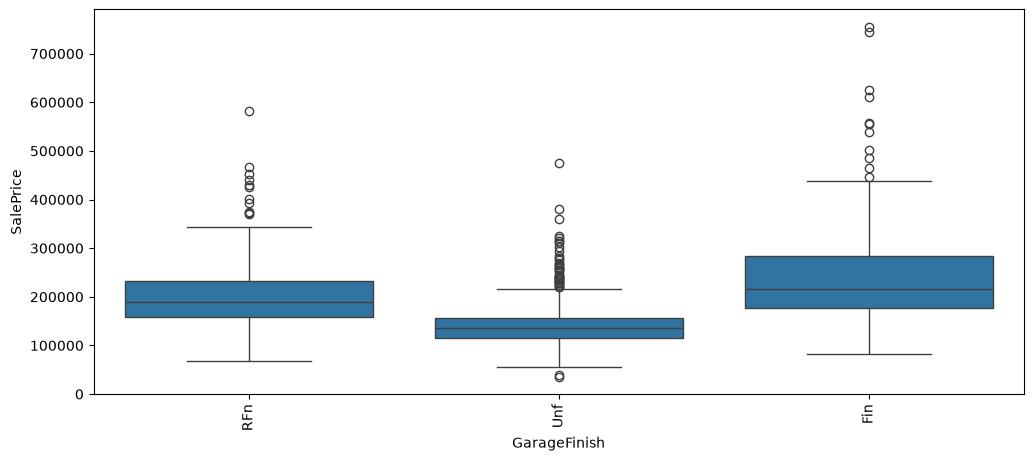


GarageQual
              median           mean  count
GarageQual                                
TA          170000.0  187489.836003   1311
Fa          115000.0  123573.354167     48
Gd          209115.0  215860.714286     14
Ex          127500.0  241000.000000      3
Po           96500.0  100166.666667      3


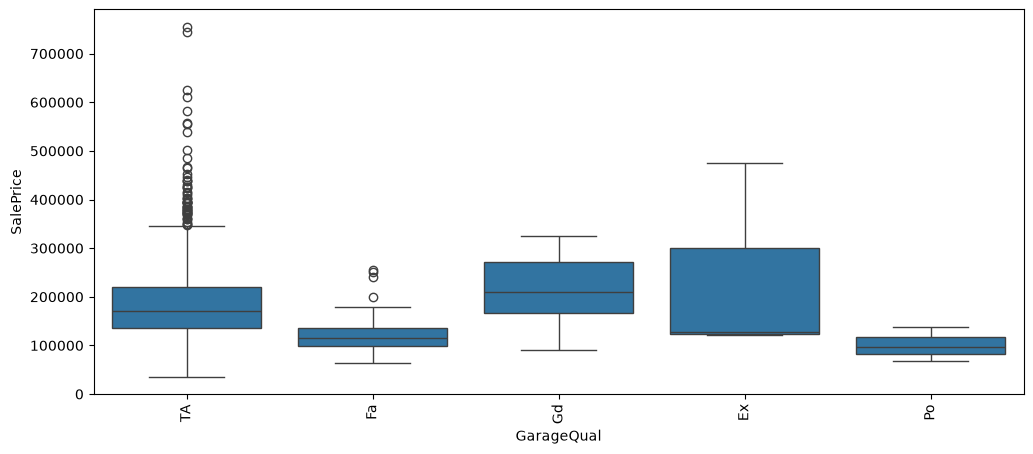


GarageCond
              median           mean  count
GarageCond                                
TA          170000.0  187885.735294   1326
Fa          114504.0  114654.028571     35
Gd          148000.0  179930.000000      9
Po          108000.0  108500.000000      7
Ex          124000.0  124000.000000      2


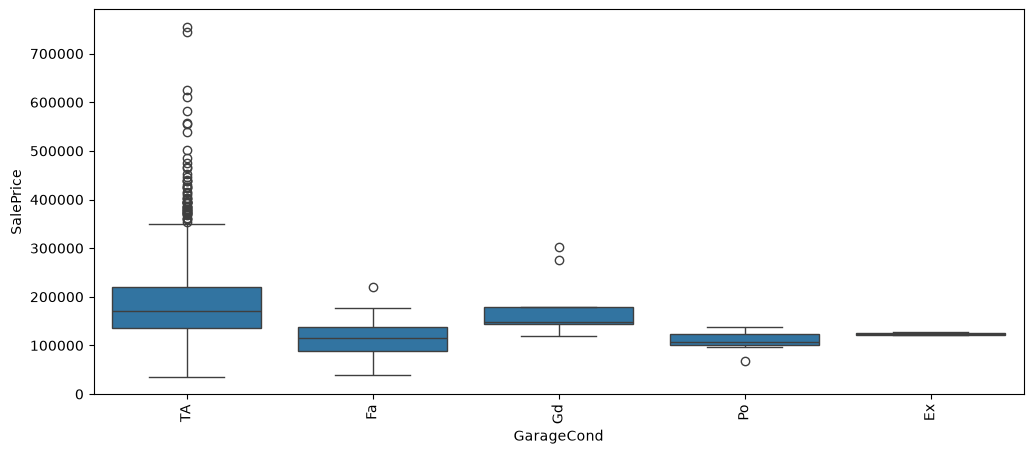


PavedDrive
              median           mean  count
PavedDrive                                
Y           168500.0  186433.973881   1340
N           111000.0  115039.122222     90
P           132250.0  132330.000000     30


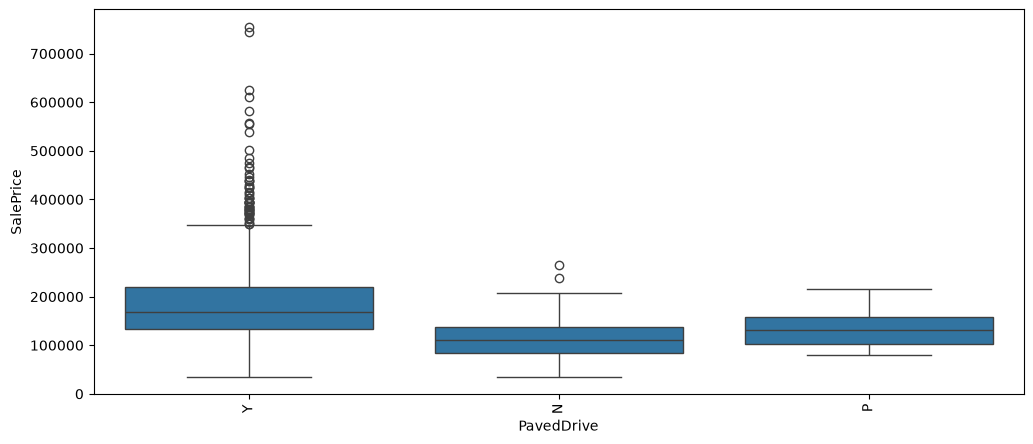


PoolQC
          median      mean  count
PoolQC                           
Gd      171000.0  201990.0      3
Ex      490000.0  490000.0      2
Fa      215500.0  215500.0      2


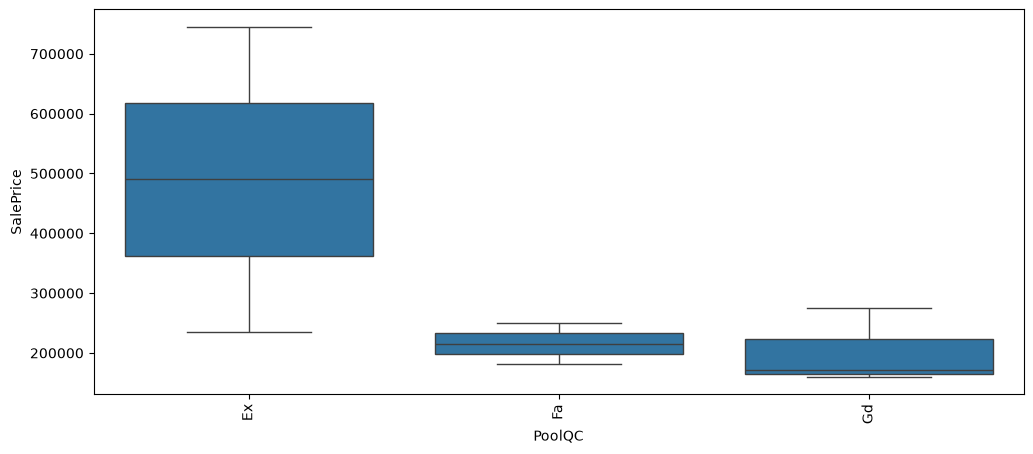


Fence
         median           mean  count
Fence                                
MnPrv  137450.0  148751.089172    157
GdPrv  167500.0  178927.457627     59
GdWo   138750.0  140379.314815     54
MnWw   130000.0  134286.363636     11


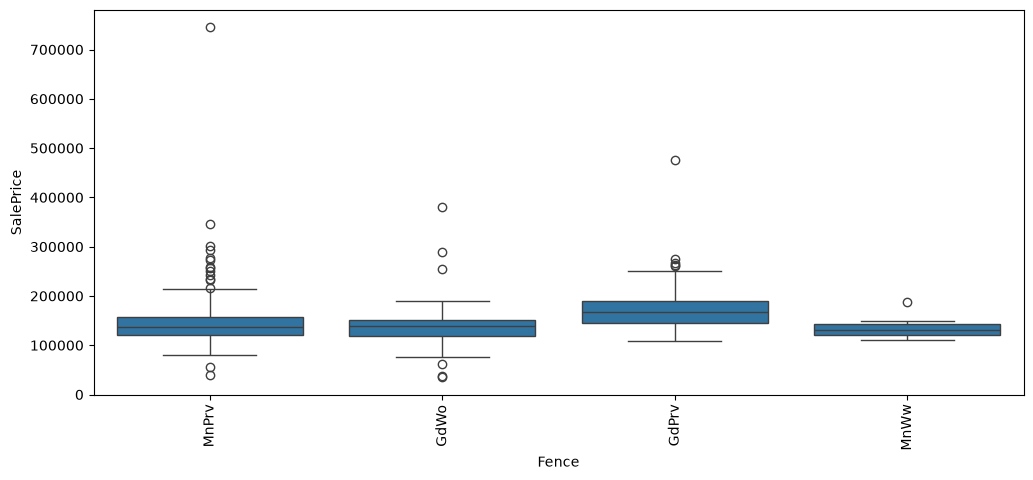

In [52]:
for col in ordinal_features:
    print(f"\n{col}")
    print(
        data.groupby(col)["SalePrice"]
        .agg(["median", "mean", "count"])
        .sort_values("count", ascending=False)
    )
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=col, y="SalePrice", data=data)
    plt.xticks(rotation=90)
    plt.show()

Порядковые признаки, связанные с качеством и состоянием основных частей дома, показывают выраженную связь с ценой. Наиболее информативными выглядят ExterQual, BsmtQual, KitchenQual, HeatingQC, GarageFinish, FireplaceQu, BsmtExposure и PavedDrive. Для некоторых остальных признаков выводы менее надёжны из-за сильного дисбаланса и малого количества объектов в отдельных категориях.

Остались временные их мало поэтому каждый проанализируем отдельно

YearBuilt — как меняется цена в зависимости от года постройки;

YearRemodAdd — влияет ли более свежий ремонт/реконструкция;

GarageYrBlt — связан ли год постройки гаража с ценой;

MoSold — есть ли сезонность по месяцу продажи;

YrSold — менялась ли цена между годами продаж.

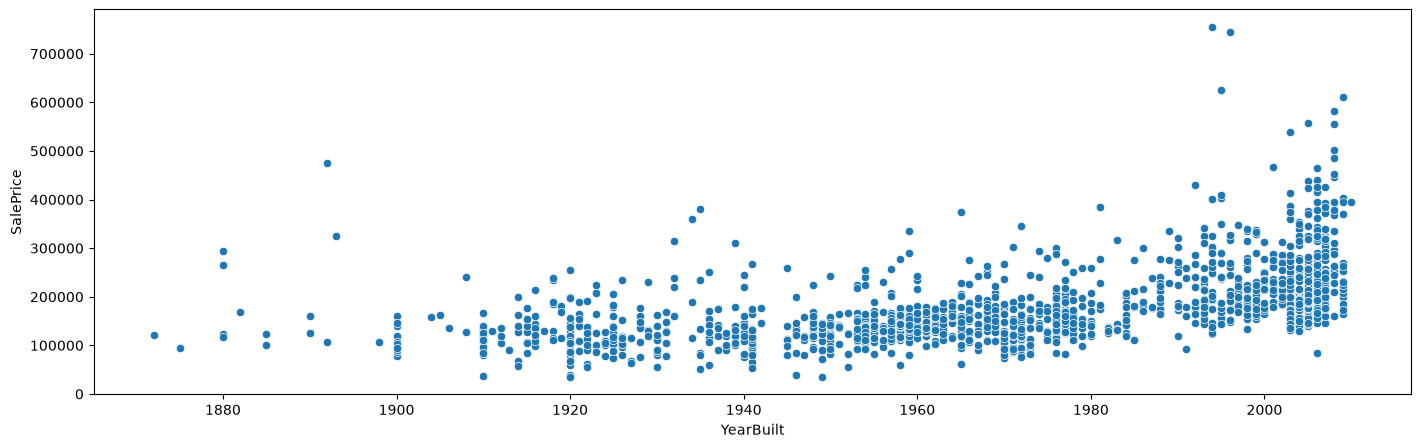

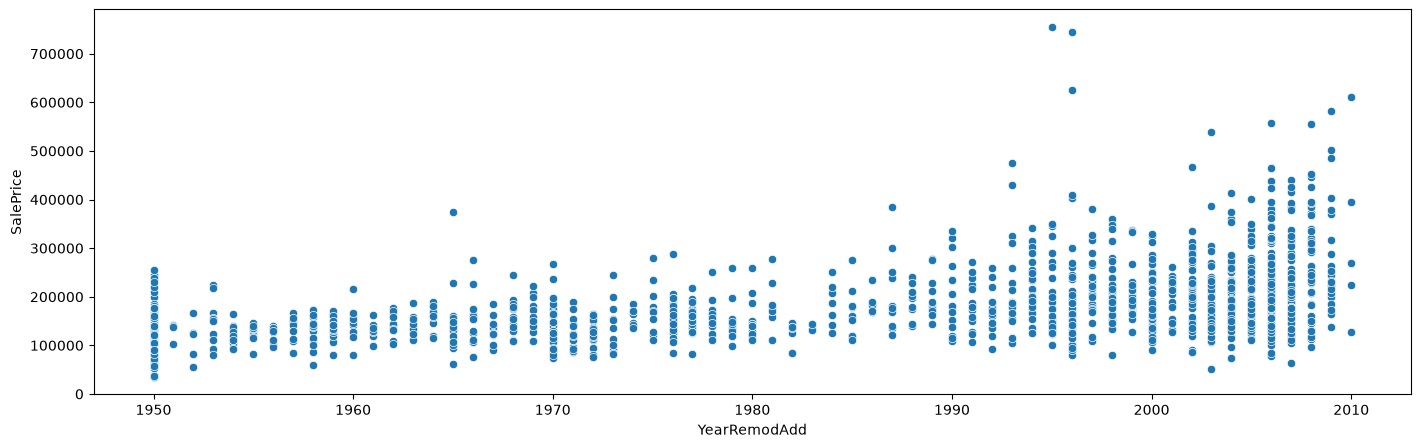

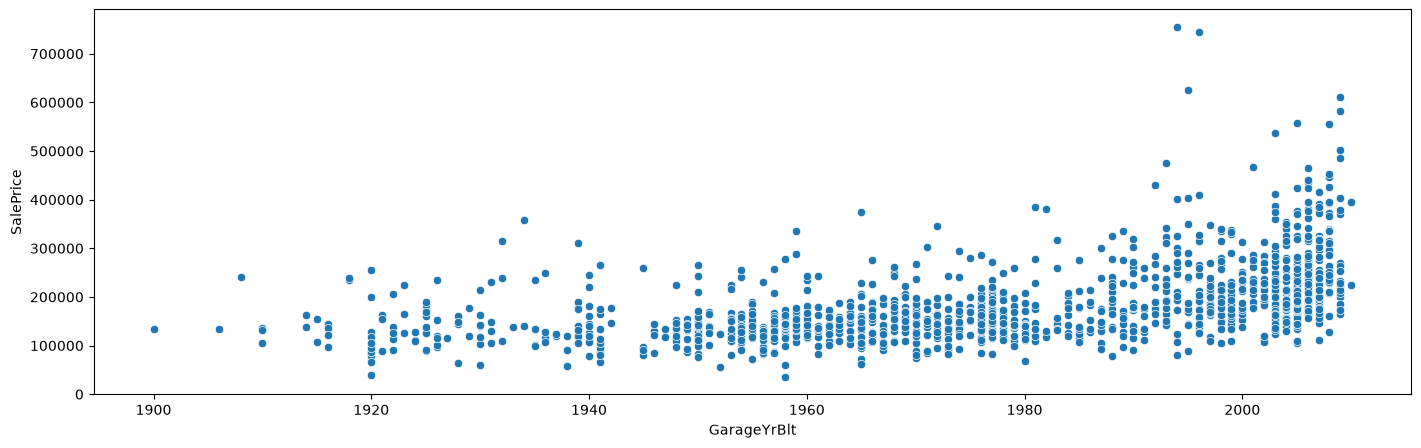

In [53]:
for col in ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]:
    plt.figure(figsize=(17, 5))
    sns.scatterplot(x=col, y="SalePrice", data=data)
    plt.show()

In [54]:
data[["YearBuilt", "YearRemodAdd", "GarageYrBlt"]].corrwith(data["SalePrice"])

YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
dtype: float64

<Axes: xlabel='MoSold', ylabel='SalePrice'>

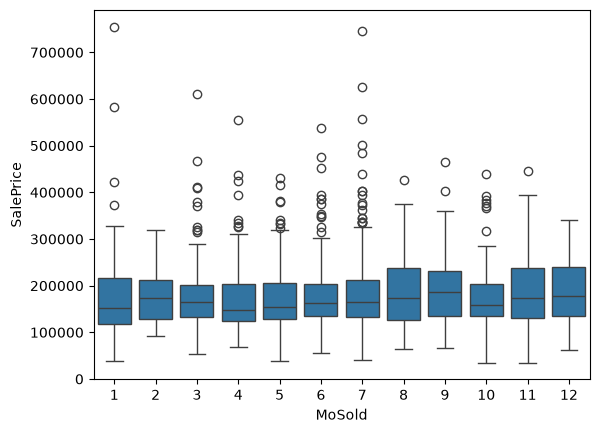

In [55]:
sns.boxplot(x="MoSold", y="SalePrice", data=data)

<Axes: xlabel='YrSold', ylabel='SalePrice'>

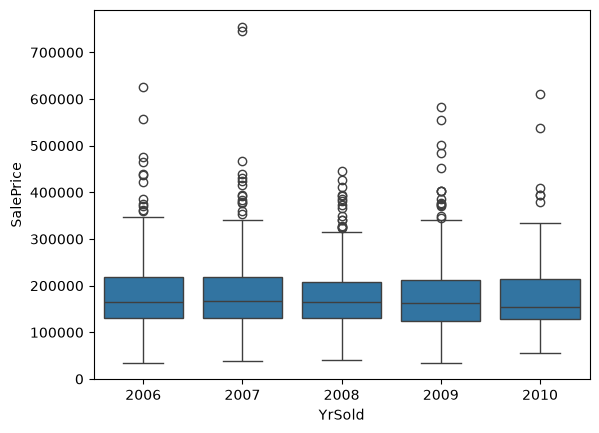

In [56]:
sns.boxplot(x="YrSold", y="SalePrice", data=data)

Временные признаки YearBuilt, YearRemodAdd и GarageYrBlt показывают умеренную положительную связь с SalePrice: более новые объекты в среднем стоят дороже. При этом зависимость выражена не очень сильно и наблюдается значительный разброс цен. MoSold и YrSold заметной связи с ценой не показывают.

теперь рассмотрим признаки на мультиколлиарность, потому что в ходе анализа были выявлены признаки, которые описывают похожие свойства.

выведем только пары у которых корреляция > 0.8

In [57]:
numeric_features = continuous_features + discrete_features + temporal_features
corr_matrix = data[numeric_features].corr().abs()

high_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()
print(high_corr[high_corr > 0.8])

TotalBsmtSF  1stFlrSF        0.819530
GrLivArea    TotRmsAbvGrd    0.825489
GarageArea   GarageCars      0.882475
YearBuilt    GarageYrBlt     0.825667
dtype: float64


При анализе мультиколлинеарности были обнаружены четыре пары признаков с высокой корреляцией. TotalBsmtSF и 1stFlrSF, а также GrLivArea и TotRmsAbvGrd оставлем, так как несмотря на сильную связь они описывают разные характеристики дома.
GarageArea и GarageCars во многом дублируют друг друга, поэтому оставляем GarageCars, а GarageArea исключаем. YearBuilt и GarageYrBlt сильно связаны, при этом YearBuilt является более общим и информативным признаком, поэтому GarageYrBlt можно удалить.


так теперь проверим категориальные признаки, переберём вручную очевидные признаки

In [58]:
pairs = [
    ("Exterior1st", "Exterior2nd"),
    ("ExterQual", "ExterCond"),
    ("BsmtQual", "BsmtCond"),
    ("BsmtFinType1", "BsmtFinType2"),
    ("GarageQual", "GarageCond"),
    ("GarageFinish", "GarageQual"),
    ("SaleType", "SaleCondition"),
]
for col1, col2 in pairs:
    table = pd.crosstab(data[col1], data[col2], normalize="index")
    strong = table.stack()
    strong = strong[strong > 0.7]
    if not strong.empty:
        print(f"\n{col1} <-> {col2}")
        print(strong.round(2))


Exterior1st <-> Exterior2nd
Exterior1st  Exterior2nd
AsbShng      AsbShng        0.85
AsphShn      AsphShn        1.00
BrkComm      Brk Cmn        1.00
CBlock       CBlock         1.00
CemntBd      CmentBd        0.97
HdBoard      HdBoard        0.87
ImStucc      ImStucc        1.00
MetalSd      MetalSd        0.96
Plywood      Plywood        0.89
Stucco       Stucco         0.80
VinylSd      VinylSd        0.97
Wd Sdng      Wd Sdng        0.86
dtype: float64

ExterQual <-> ExterCond
ExterQual  ExterCond
Ex         TA           0.92
Gd         TA           0.93
TA         TA           0.85
dtype: float64

BsmtQual <-> BsmtCond
BsmtQual  BsmtCond
Ex        TA          0.91
Fa        TA          0.71
Gd        TA          0.94
TA        TA          0.92
dtype: float64

BsmtFinType1 <-> BsmtFinType2
BsmtFinType1  BsmtFinType2
ALQ           Unf             0.75
BLQ           Unf             0.76
GLQ           Unf             0.94
Rec           Unf             0.83
Unf           Unf       

При ручной проверке связанных категориальных признаков наиболее явное дублирование наблюдается между Exterior1st и Exterior2nd: для большинства категорий материал внешней отделки совпадает, поэтому Exterior2nd можно исключить. Также GarageQual и GarageCond содержат во многом похожую информацию, поэтому оставим GarageQual, а GarageCond исключим. Для остальных рассмотренных пар высокие доли в основном связаны с сильным преобладанием отдельных категорий, а не с прямым дублированием признаков, поэтому их пока оставляем.

Так теперь обработаем аномальные значения которые были замечены.

А именно очень дорогие дома (SalePrice > 500000), большие значения GrLivArea и большие значения LotArea

In [59]:
data[data["SalePrice"] > 500000][
    ["SalePrice", "GrLivArea", "LotArea", "OverallQual"]
].sort_values("SalePrice")

,SalePrice,GrLivArea,LotArea,OverallQual
178,501837,2234,17423,9
769,538000,3279,53504,8
440,555000,2402,15431,10
1046,556581,2868,16056,9
803,582933,2822,13891,9
898,611657,2364,12919,9
1169,625000,3627,35760,10
1182,745000,4476,15623,10
691,755000,4316,21535,10


In [60]:
data.nlargest(10, "GrLivArea")[
    ["GrLivArea", "SalePrice", "LotArea", "OverallQual"]
].sort_values("GrLivArea")

,GrLivArea,SalePrice,LotArea,OverallQual
769,3279,538000,53504,8
635,3395,200000,10896,6
1268,3447,381000,14100,8
304,3493,295000,18386,7
185,3608,475000,22950,10
1169,3627,625000,35760,10
691,4316,755000,21535,10
1182,4476,745000,15623,10
523,4676,184750,40094,10
1298,5642,160000,63887,10


In [61]:
data.nlargest(10, "LotArea")[
    ["Id", "LotArea", "SalePrice", "GrLivArea", "OverallQual"]
].sort_values("LotArea")

,Id,LotArea,SalePrice,GrLivArea,OverallQual
384,385,53107,240000,1953,6
457,458,53227,256000,1663,4
769,770,53504,538000,3279,8
1396,1397,57200,160000,1687,5
1298,1299,63887,160000,5642,10
451,452,70761,280000,1533,7
706,707,115149,302000,1824,7
249,250,159000,277000,2144,6
335,336,164660,228950,1786,5
313,314,215245,375000,2036,7


определим самые странные объекты и посмотрим на них.

In [62]:
ids = [804, 899, 524, 1299, 385, 458, 1397, 335]
data[data["Id"].isin(ids)][
    ["SalePrice", "GrLivArea", "LotArea", "OverallQual", "YearBuilt"]
]

,SalePrice,GrLivArea,LotArea,OverallQual,YearBuilt
334,192000,1638,9042,6,1998
384,240000,1953,53107,6,1992
457,256000,1663,53227,4,1954
523,184750,4676,40094,10,2007
803,582933,2822,13891,9,2008
898,611657,2364,12919,9,2009
1298,160000,5642,63887,10,2008
1396,160000,1687,57200,5,1948


Наиболее явными выбросами являются объекты 524 и 1299, имеющие экстремально большую жилую площадь при непропорционально низкой цене. Объекты 458 и 1397 также выглядят подозрительно при сравнении с похожими домами, однако их аномальность менее однозначна, поэтому окончательное решение об их удалении будет принято по результатам кросс-валидации.

посмотрим на Nan

In [63]:
missing = pd.DataFrame(
    {"count": data.isnull().sum(), "percent": data.isnull().mean() * 100}
)

missing = missing[missing["count"] > 0].sort_values("percent", ascending=False)

missing

,count,percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


В датасете присутствуют признаки с пропущенными значениями. Некоторые признаки содержат большую долю пропусков, поэтому перед обучением модели потребуется определить природу этих пропусков и выбрать подходящий способ обработки.

по очистке последнее проверим дубликаты и невозможные занчения


In [64]:
data.duplicated().sum()

np.int64(0)

In [65]:
data[
    (data["YearBuilt"] > data["YrSold"])
    | (data["YearRemodAdd"] < data["YearBuilt"])
    | (data["GarageYrBlt"] > data["YrSold"])
][["Id", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]]

,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold


Теперь посмотрим на Matual Information с таргетом

In [69]:
from sklearn.feature_selection import mutual_info_regression

X = data.drop(columns=["SalePrice", "Id"]).copy()
y = data["SalePrice"]

categorical_cols = [
    col for col in nominal_features + ordinal_features if col in X.columns
]

for col in categorical_cols:
    X[col] = X[col].fillna("Missing")
    X[col] = pd.factorize(X[col])[0]

numeric_cols = X.columns.difference(categorical_cols)

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

discrete_mask = [
    col in categorical_cols or col in discrete_features for col in X.columns
]

mi = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=0)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

mi_scores.head(20)

OverallQual     0.570529
Neighborhood    0.531615
GrLivArea       0.482022
TotalBsmtSF     0.368395
GarageCars      0.367013
GarageArea      0.362783
YearBuilt       0.361503
BsmtQual        0.335537
ExterQual       0.324133
KitchenQual     0.323945
1stFlrSF        0.309729
GarageYrBlt     0.297688
MSSubClass      0.283589
FullBath        0.261524
GarageFinish    0.257192
YearRemodAdd    0.250049
TotRmsAbvGrd    0.223169
LotFrontage     0.219965
FireplaceQu     0.210584
GarageType      0.207004
dtype: float64

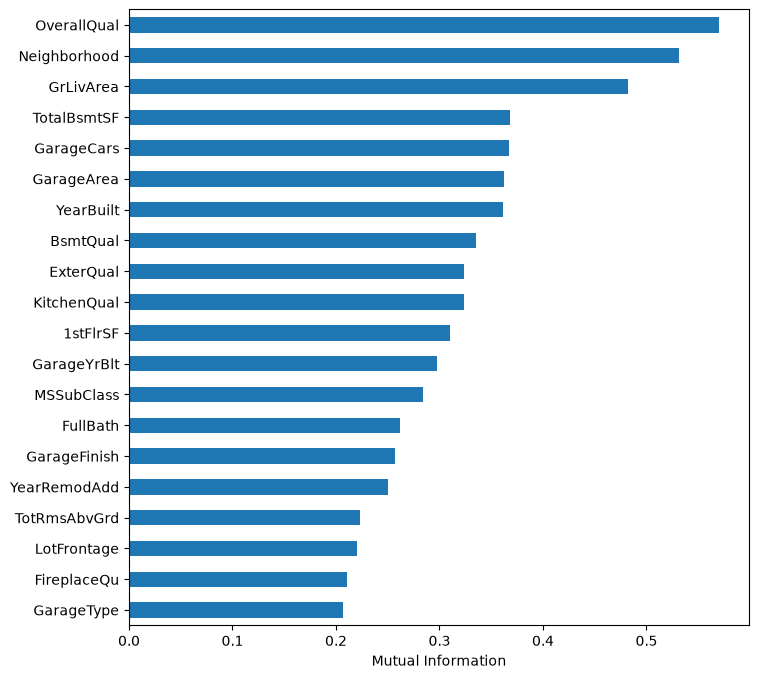

In [67]:
mi_scores.head(20).sort_values().plot.barh(figsize=(8, 8))
plt.xlabel("Mutual Information")
plt.show()

Mutual Information подтвердил результаты предварительного EDA. Наиболее информативными признаками относительно SalePrice являются OverallQual, Neighborhood, GrLivArea, TotalBsmtSF, характеристики гаража, год постройки и признаки качества отделки. Особенно выделяется Neighborhood, который имеет высокую связь с целевой переменной несмотря на категориальный тип. Некоторые признаки, слабо выраженные на отдельных графиках, например MSSubClass, также показывают заметную информативность по MI, что указывает на возможную нелинейную зависимость.

мы уже знаем что у SalePrice распределение отклоненно от нормального и имеет положительную ассиметрию, посмотрим на распределения других признаков.

In [68]:
skewness = data[continuous_features].skew()
skewed_features = skewness[skewness.abs() > 0.75].sort_values(ascending=False)
skewed_features

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
BsmtFinSF2        4.255261
ScreenPorch       4.122214
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64

Анализ асимметрии непрерывных признаков показал, что значительная часть признаков имеет выраженную положительную асимметрию. Наиболее сильно смещены MiscVal, PoolArea, LotArea, 3SsnPorch и LowQualFinSF. Также заметная асимметрия наблюдается у BsmtFinSF2, ScreenPorch, EnclosedPorch, MasVnrArea, OpenPorchSF, LotFrontage, BsmtFinSF1, WoodDeckSF, TotalBsmtSF, 1stFlrSF, GrLivArea, BsmtUnfSF и 2ndFlrSF.
Для этих признаков на этапе preprocessing стоит рассмотреть преобразования, уменьшающие асимметрию, например log1p, и проверить их влияние на качество модели. При этом некоторые признаки, например PoolArea, MiscVal и площади веранд, имеют сильную асимметрию в том числе из-за большого количества нулевых значений, поэтому необходимость их преобразования следует проверять отдельно.

В ходе анализа были изучены распределение целевой переменной, числовые, категориальные, порядковые и временные признаки, их связь с SalePrice, мультиколлинеарность, пропущенные значения, выбросы, Mutual Information и асимметрия распределений.
Были выявлены наиболее информативные признаки, потенциально избыточные признаки, подозрительные наблюдения, признаки с большим количеством пропусков и сильно смещёнными распределениями.
На этапе EDA данные намеренно не подвергаются окончательному preprocessing и feature engineering. Все обнаруженные особенности и идеи будут сохранены в Notes и затем проверены экспериментально на этапе обучения с помощью cross-validation.
В частности, будут отдельно тестироваться обработка пропусков, удаление/сохранение спорных выбросов, преобразование сильно асимметричных признаков и SalePrice, удаление коррелирующих признаков, различные способы кодирования категориальных признаков и новые признаки, созданные на основе исходных данных.
Основной критерий принятия окончательных решений — изменение качества модели на cross-validation, а не только результаты EDA.